# Modellierung mit Chronos-2 — PM2.5 Beijing (nur Chronos-2, variables Split-Datum + Luftschadstoffe)

**Capstone-Projekt · CRISP-DM Phase 4 (Modeling)**
Bettina Gertjerenken · Kai Steffen

Fokussiertes Analogon zu `03_Modellierung_Prophet_Beijing.ipynb`, **nur mit Chronos-2** (kein PatchTST) — baut
auf `03_Modellierung_Chronos2_variabel_Beijing.ipynb` auf und ergänzt die vier **Luftschadstoff-Regressoren**
(`SO2`, `NO2`, `CO`, `O3`) aus der aktualisierten Datenaufbereitung
(`02_Datenaufbereitung_Prophet_Beijing_mit_Luftschadstoffen.ipynb`). Vier Dinge sind hier flexibler als im
ursprünglichen Prophet-Notebook:

1. **Split-Datum frei wählbar** (`SPLIT_DATUM`) — statt fest an die vorbereiteten `prophet_train_*.csv` /
   `prophet_test_*.csv`-Dateien gebunden zu sein, werden Train und Test hier **aus einer durchgehenden
   Zeitreihe** neu geschnitten. So lässt sich z. B. prüfen, wie stabil die Ergebnisse über verschiedene
   Testzeiträume hinweg sind.
2. **Regressoren-Auswahl mit Zukunfts-/Vergangenheits-Unterscheidung**: `REGRESSOREN_ZUKUNFT` (Chronos-2 bekommt
   diese Werte auch für den Prognosezeitraum, z. B. weil sie aus einer Wettervorhersage stammen würden) und
   `REGRESSOREN_VERGANGENHEIT` (Chronos-2 sieht nur die Historie, muss den Rest selbst ableiten) — beliebig aus
   den verfügbaren Spalten zusammenstellbar. **Neu:** `SO2`/`NO2`/`CO`/`O3` sind standardmäßig als
   `REGRESSOREN_VERGANGENHEIT` eingeordnet (siehe Abschnitt 2 für die Begründung) — nicht als bekannte
   Zukunftskovariate nutzbar, nur als zusätzlicher Kontext.
3. **Finale multivariate Prognose**: am Ende werden alle Stationen **gemeinsam** (Chronos-2s native
   Group-Attention) mit den behandelten Daten, Feiertagen, den gewählten Regressoren (inkl. Luftschadstoffe)
   und Log-Ziel vorhergesagt — die "Summe" aller Konfigurationsstufen in einem Schritt.
4. **Interaktives Dashboard** (Abschnitt 10): Split-Datum, Aggregation, Horizont, Feiertage, Regressoren
   (inkl. Luftschadstoffe), Log, Stationen und optionales Glätten des Trainingsrauschens — alles per Widget
   steuerbar, ausschließlich Chronos-2 vs. Seasonal Naive.

> ⚠️ **Voraussetzung:** Die CSVs unter `../data/prepared/basis/` und `../data/prepared/behandelt/` müssen aus
> dem **aktualisierten** Datenaufbereitungs-Notebook stammen (mit `SO2`/`NO2`/`CO`/`O3`-Spalten) — mit den
> CSVs aus der ursprünglichen Datenaufbereitung fehlen diese vier Spalten und `chronos_predict()` bricht mit
> einem `KeyError` ab.

> ⚠️ **Wichtiger Hinweis zum variablen Split-Datum:** Die `behandelt`-Variante kappt Ausreißer auf das
> 99,9-Perzentil der **ursprünglichen** Trainingsdaten (Stand Kapitel 03, Split am 1.3.2016) — dieses Kappen
> wird durch ein anderes `SPLIT_DATUM` hier **nicht neu berechnet**. Weicht dein gewähltes Split-Datum stark vom
> 1.3.2016 ab, kann das Kappen dann teilweise im jetzigen Test- statt Trainingszeitraum liegen (oder umgekehrt
> nicht den ganzen jetzigen Trainingszeitraum abdecken). Für sauber am neuen Split neu berechnete Kappungsgrenzen
> müsste Kapitel 02 (Datenaufbereitung) mit dem neuen Datum erneut laufen.

> ⚙️ **Umgebung:** `pip install "chronos-forecasting>=2.0" holidays "pandas[pyarrow]" ipywidgets`. Modellgewichte
> werden beim ersten Lauf von Hugging Face geladen (Internetzugriff nötig). `ipywidgets` wird nur für das
> interaktive Dashboard in Abschnitt 10 gebraucht.
> 📁 **Voraussetzung:** wie im Prophet-Notebook müssen `../data/prepared/basis/` und `../data/prepared/behandelt/`
> gefüllt sein (Kapitel 02, aktualisierte Datenaufbereitung inkl. Luftschadstoffe).


## 1. Bibliotheken & Versionen


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output

import chronos
from chronos import Chronos2Pipeline
import holidays

print("chronos-forecasting-Version:", chronos.__version__)
print("torch-Version:             ", torch.__version__, "| CUDA verfuegbar:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 13, "axes.titleweight": "bold"})
AMBER, RUST, SLATE, TEAL, MOSS = "#E0912F", "#C4471C", "#3A4148", "#1C7293", "#2C5F2D"
CHRONOSFARBE = "#7B2CBF"   # Violett: einheitliche Farbe fuer alle Chronos-2-Linien


chronos-forecasting-Version: 2.3.1
torch-Version:              2.6.0+cu124 | CUDA verfuegbar: True


## 2. Konfiguration

Alles Konfigurierbare an einem Ort: Station, **Split-Datum**, verfügbare Regressoren und ihre Einordnung in
**Zukunft** (`REGRESSOREN_ZUKUNFT`) vs. **Vergangenheit** (`REGRESSOREN_VERGANGENHEIT`).

- `REGRESSOREN_ZUKUNFT`: geht in `context_df` **und** `future_df` — Chronos-2 "kennt" diese Werte auch für den
  Prognosezeitraum. Bei uns: die fünf Wetter-Variablen + `wd_sin`/`wd_cos` — die tatsächlich gemessenen Werte
  dienen als Stellvertreter für eine Wettervorhersage (derselbe Fairness-Kompromiss wie in den bisherigen
  Notebooks).
- `REGRESSOREN_VERGANGENHEIT`: geht nur in `context_df` — Chronos-2 sieht nur die Historie dieser Variable.
  **Neu:** `SO2`, `NO2`, `CO`, `O3` (aus der aktualisierten Datenaufbereitung). Anders als Wetter sind
  Luftschadstoffe selbst Teil dessen, was wir eigentlich vorhersagen wollen — ihre *zukünftigen* Werte als
  "bekannt" zu behandeln wäre unrealistisch und würde Informationen durchsickern lassen, die der Zielgröße
  inhaltlich sehr nahekommen. Deshalb bewusst nur als Kontext, nicht als Zukunftskovariate.
- Spalten aus `REGRESSOREN_VERFUEGBAR`, die in **keiner** der beiden Listen stehen, werden schlicht nicht
  verwendet.


In [2]:
STATION = "Dongsi"          # Beispielstation fuer die Detail-Analyse
PREP = Path("../data/prepared_chronos")

# --- Split-Datum: frei aenderbar (siehe Warnhinweis oben zur 'behandelt'-Kappung) -----------------
SPLIT_DATUM = "2016-12-15"        # Format "JJJJ-MM-TT", identisch zum urspruenglichen Prophet-Split

# --- Regressoren: Auswahl + Zukunft/Vergangenheit ---------------------------------------------------
# Aufgeteilt wie im aktualisierten Datenaufbereitungs-Notebook (02_Datenaufbereitung_..._mit_Luftschadstoffen):
# Wetter kann in einer operativen Prognose aus einer Wettervorhersage kommen (Zukunft bekannt), die vier
# Luftschadstoffe SO2/NO2/CO/O3 sind dagegen selbst Teil dessen, was wir vorhersagen wollen -- deren
# Zukunftswerte als "bekannt" zu behandeln waere unrealistisch und liesse zielgroessen-nahe Information
# durchsickern. Deshalb NUR als Vergangenheits-/Kontext-Regressoren nutzbar.
REGRESSOREN_VERFUEGBAR = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos",
                          "SO2", "NO2", "CO", "O3",
                          "tage_seit_cny", "cny_naehe", "jahr_sin", "jahr_cos"]

REGRESSOREN_ZUKUNFT       = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos",
                             "tage_seit_cny", "cny_naehe", "jahr_sin", "jahr_cos"]   # -> context_df UND future_df
REGRESSOREN_VERGANGENHEIT = ["SO2", "NO2", "CO", "O3"]                                     # -> nur context_df

assert set(REGRESSOREN_ZUKUNFT) <= set(REGRESSOREN_VERFUEGBAR), "unbekannter Regressor in REGRESSOREN_ZUKUNFT"
assert set(REGRESSOREN_VERGANGENHEIT) <= set(REGRESSOREN_VERFUEGBAR), "unbekannter Regressor in REGRESSOREN_VERGANGENHEIT"
assert not (set(REGRESSOREN_ZUKUNFT) & set(REGRESSOREN_VERGANGENHEIT)), \
    "ein Regressor darf nicht gleichzeitig in Zukunft und Vergangenheit stehen"

HORIZONTE = [8, 24, 48, 72]        # kurzfristige Prognose-Zeitraeume in Stunden
SAISON_M = 24                      # Saisonperiode fuer Seasonal Naive & MASE (Tagesmuster), stuendliche Daten
FREQ = "h"                         # Stundendaten -- explizit an Chronos-2 durchreichen (Auto-Inferenz
                                    # scheitert leicht an Luecken/DST)

# Chronos-2 rechnet auf 4h-aggregierten Daten (weniger Schritte -> schneller, glatteres Signal).
# WICHTIG: das aendert die Aufgabe (4h-Mittelwerte sind leichter zu treffen als Einzelstunden). Auf
# AGG_STUNDEN=1 setzen fuer volle Stundenaufloesung.
AGG_STUNDEN = 4
FREQ_CHRONOS = f"{AGG_STUNDEN}h"
SAISON_M_CHRONOS = SAISON_M // AGG_STUNDEN   # 6 Vier-Stunden-Bloecke = 1 Tag

# Chinesischer Feiertagskalender ueber das Paket 'holidays' (Ersatz fuer Prophets add_country_holidays("CN")).
CN_HOLIDAYS = holidays.country_holidays("CN", years=range(2013, 2018))

def add_feiertag(df):
    '''Fuegt eine 0/1-Spalte "feiertag" hinzu -- im Voraus bekannt, kein Leakage. Zaehlt immer als
    Zukunfts-Kovariate (deterministisch aus dem Kalender ableitbar).'''
    d = df.copy()
    d["feiertag"] = d["ds"].dt.date.astype("O").map(lambda t: 1 if t in CN_HOLIDAYS else 0)
    return d


# --- Saisonalitaets-Kovariaten: kontinuierliche CNY-Naehe + zyklische Jahreszeit -------------------
# Warum zusaetzlich zu "feiertag": das binaere Flag markiert nur die amtlich festgelegten Feiertage
# (5-9 Tage/Jahr) als hartes 0/1 -- es kennt weder die Tage DAVOR (Vorfreude-/Reiseverkehr, ansteigende
# Emissionen durch Feuerwerk-Vorbereitung) noch die WOCHEN DANACH (Betriebe fahren die Produktion erst
# schrittweise wieder hoch). Chinesisches Neujahr faellt zudem jedes Jahr auf ein anderes Gregorianisches
# Datum (Mondkalender) -- ein reines Tag-des-Jahres-Merkmal wuerde das NICHT konsistent abbilden.
# `tage_seit_cny` / `cny_naehe` loesen beides: sie sind relativ zum tatsaechlichen (lunaren) CNY-Datum
# jedes Jahres berechnet und aendern sich graduell statt abrupt.
_CNY_KALENDER = holidays.country_holidays("CN", years=range(2012, 2019))   # 1 Jahr Rand fuer Uebergaenge an den Datenraendern
_CNY_NACH_JAHR = {}
for _datum, _name in _CNY_KALENDER.items():
    if "\u6625\u8282" in _name:   # 春节 = "Fruehlingsfest" / Chinesisches Neujahr
        _CNY_NACH_JAHR.setdefault(_datum.year, []).append(_datum)
CNY_TERMINE = {jahr: min(daten) for jahr, daten in _CNY_NACH_JAHR.items()}   # erster markierter CNY-Tag je Jahr
_CNY_SORTIERT = np.array(sorted(pd.Timestamp(d) for d in CNY_TERMINE.values()), dtype="datetime64[ns]")


def add_saison_kovariaten(df, cny_sigma_tage=6.0):
    '''Fuegt vier deterministische, kalenderbasierte Kovariaten hinzu (alle im Voraus bekannt, also fuer
    REGRESSOREN_ZUKUNFT geeignet):
      - tage_seit_cny: signierter Abstand in Tagen zum naechstgelegenen Chinesischen Neujahr (negativ
        VOR, positiv NACH dem Fest) -- kontinuierlich statt eines harten Datumsflags.
      - cny_naehe: glockenfoermige "Naehe zu CNY" (0..1, Gauss-Bump um tage_seit_cny=0 mit Breite
        cny_sigma_tage), faengt die graduelle Vor-/Nachwirkung ein statt eines abrupten Ein/Aus.
      - jahr_sin / jahr_cos: zyklische Kodierung des Tags im Jahr (sin/cos statt roher Tag-des-Jahres-
        Zahl, damit der Jahreswechsel keinen kuenstlichen Sprung erzeugt) -- bildet die generelle
        Heizsaison-/Wintersmog-Saisonalitaet explizit ab, zusaetzlich zu dem, was Chronos-2 ohnehin aus
        der Historie lernen kann.
    '''
    d = df.copy()
    ds_arr = d["ds"].values.astype("datetime64[ns]")

    idx_hi = np.clip(np.searchsorted(_CNY_SORTIERT, ds_arr), 0, len(_CNY_SORTIERT) - 1)
    idx_lo = np.clip(idx_hi - 1, 0, len(_CNY_SORTIERT) - 1)
    diff_hi = (_CNY_SORTIERT[idx_hi] - ds_arr) / np.timedelta64(1, "D")     # >=0, CNY liegt in der Zukunft
    diff_lo = (ds_arr - _CNY_SORTIERT[idx_lo]) / np.timedelta64(1, "D")     # >=0, CNY liegt in der Vergangenheit
    naeher_ist_hi = diff_hi < diff_lo
    tage_seit_cny = np.where(naeher_ist_hi, -diff_hi, diff_lo)              # negativ vor, positiv nach CNY

    d["tage_seit_cny"] = tage_seit_cny
    d["cny_naehe"] = np.exp(-0.5 * (tage_seit_cny / cny_sigma_tage) ** 2)

    doy = d["ds"].dt.dayofyear.to_numpy()
    d["jahr_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["jahr_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return d


### 2b. Kurzer Sanity-Check: Saisonalitäts-Kovariaten

Bevor es weitergeht, kurz visuell prüfen, dass `cny_naehe` tatsächlich sinnvoll um das echte CNY-Datum
herum ansteigt/abfällt (statt z. B. verschoben oder invertiert zu sein).

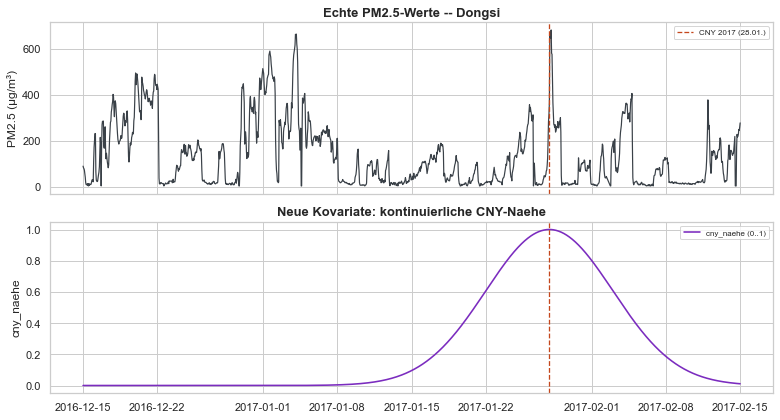

CNY-Termine (erster markierter Tag je Jahr):
  2012: 2012-01-23
  2013: 2013-02-10
  2014: 2014-01-31
  2015: 2015-02-19
  2016: 2016-02-08
  2017: 2017-01-28
  2018: 2018-02-16


In [5]:
def lade_gesamt(variante, station=STATION):
    '''variante = 'basis' oder 'behandelt'. Laedt die vorbereitete CSV fuer die Station als EINE
    durchgehende Zeitreihe -- der Split erfolgt bewusst NICHT hier, sondern flexibel ueber split_bei(),
    damit SPLIT_DATUM frei waehlbar bleibt. Haengt zusaetzlich die kalenderbasierten Saisonalitaets-
    Kovariaten (tage_seit_cny, cny_naehe, jahr_sin, jahr_cos) an -- rein deterministisch aus "ds",
    also fuer jede Station/jeden Aufruf automatisch verfuegbar, kein zusaetzlicher Merge-Schritt noetig.'''
    df = pd.read_csv(PREP / variante / f"chronos_{station}.csv", parse_dates=["ds"])
    df = df.sort_values("ds").reset_index(drop=True)
    return add_saison_kovariaten(df)

# --- 2b. Diagnose: Saisonalitaets-Kovariaten rund um Chinesisch Neujahr -----------------------------
# Zeigt tage_seit_cny / cny_naehe im Vergleich zu den echten PM2.5-Werten um CNY 2017 -- als schneller
# Sanity-Check, dass die neuen Kovariaten (Abschnitt 2) tatsaechlich das tun, was sie sollen: graduell
# vor/nach dem Fest ansteigen/abfallen statt abrupt wie das binaere feiertag-Flag.
g_cny_check = lade_gesamt("basis", station=STATION)
fenster_cny = g_cny_check[(g_cny_check["ds"] >= "2016-12-15") & (g_cny_check["ds"] <= "2017-02-15")]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(fenster_cny["ds"], fenster_cny["y"], color=SLATE, lw=1.2)
axes[0].axvline(pd.Timestamp(CNY_TERMINE[2017]), color=RUST, ls="--", lw=1.3, label="CNY 2017 (28.01.)")
axes[0].set_ylabel("PM2.5 (\u00b5g/m\u00b3)"); axes[0].set_title(f"Echte PM2.5-Werte -- {STATION}")
axes[0].legend(loc="best", fontsize=8)

axes[1].plot(fenster_cny["ds"], fenster_cny["cny_naehe"], color=CHRONOSFARBE, lw=1.6, label="cny_naehe (0..1)")
axes[1].axvline(pd.Timestamp(CNY_TERMINE[2017]), color=RUST, ls="--", lw=1.3)
axes[1].set_ylabel("cny_naehe"); axes[1].set_title("Neue Kovariate: kontinuierliche CNY-Naehe")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

print("CNY-Termine (erster markierter Tag je Jahr):")
for jahr, datum in sorted(CNY_TERMINE.items()):
    print(f"  {jahr}: {datum}")


## 3. Hilfsfunktionen: Laden, Split, Fehlermaße

**Neu gegenüber den bisherigen Notebooks:** `lade_gesamt()` lädt Train+Test **zusammen** als eine durchgehende
Zeitreihe (statt einer festen Aufteilung), `split_bei()` teilt sie anschließend an einem **beliebigen**
`split_datum`. So lässt sich der Split unabhängig von den festen Dateien variieren.


In [6]:


def split_bei(df, split_datum=SPLIT_DATUM):
    '''Teilt eine durchgehende Zeitreihe an split_datum in (train, test). train enthaelt alles VOR
    split_datum, test alles AB (einschliesslich) split_datum -- test beginnt also GENAU am Split-Datum,
    analog zu "ab Testbeginn kennen wir keine echten Werte mehr" im Prophet-Notebook.'''
    grenze = pd.Timestamp(split_datum)
    train = df[df["ds"] <  grenze].reset_index(drop=True)
    test  = df[df["ds"] >= grenze].reset_index(drop=True)
    return train, test


# --- die vier Fehlermasse -----------------------------------------------------
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat) ** 2)))
def mape(y, yhat): return float(np.mean(np.abs((y - yhat) / y)) * 100)

def mase_skala(train_y, m=SAISON_M):
    a = np.asarray(train_y, dtype=float)
    return float(np.nanmean(np.abs(a[m:] - a[:-m])))

def mase(y, yhat, skala):
    return float(mae(y, yhat) / skala)

def jahres_fehler(out, skala):
    return {"MAE": mae(out["y"], out["yhat"]), "RMSE": rmse(out["y"], out["yhat"]),
            "MASE": mase(out["y"], out["yhat"], skala), "MAPE %": mape(out["y"], out["yhat"])}

def fehler_horizonte(out, skala, horizonte=HORIZONTE, schritt_stunden=1):
    o = out.sort_values("ds").reset_index(drop=True)
    zeilen = []
    for h in list(horizonte) + [None]:
        n = len(o) if h is None else max(1, h // schritt_stunden)
        w = o.iloc[:n]
        name = f"{h} h" if h is not None else "ganzes Testfenster"
        zeilen.append({"Horizont": name, "MAE": mae(w["y"], w["yhat"]),
                       "RMSE": rmse(w["y"], w["yhat"]),
                       "MASE": mase(w["y"], w["yhat"], skala),
                       "MAPE %": mape(w["y"], w["yhat"])})
    return pd.DataFrame(zeilen)


def regularize(df, spalten=None):
    '''Bringt einen Frame auf ein luecken-freies Stundenraster (freq=FREQ). Fehlende Stunden werden
    linear interpoliert (Zielgroesse + numerische Regressoren); eine binaere Spalte wie 'feiertag'
    wird stattdessen vorwaerts gefuellt. Chronos-2 braucht ein regelmaessiges Raster, sonst scheitert
    entweder die Frequenz-Erkennung oder predict_df()s interne Zeitstempel-Pruefung.'''
    spalten = spalten or [c for c in df.columns if c != "ds"]
    d = df.set_index("ds").sort_index()
    voll = pd.date_range(d.index.min(), d.index.max(), freq=FREQ)
    d = d.reindex(voll)
    for c in spalten:
        if c == "feiertag":
            d[c] = d[c].ffill().bfill()
        else:
            d[c] = d[c].interpolate(limit_direction="both")
    d.index.name = "ds"
    return d.reset_index()


def aggregiere(df, stunden=AGG_STUNDEN, spalten=None):
    '''Aggregiert einen luecken-freien Stundenframe (siehe regularize()) auf `stunden`-Stunden-Bins
    (Mittelwert je Bin, ausgerichtet auf 00/04/08/...-Uhr-Grenzen).'''
    spalten = spalten or [c for c in df.columns if c != "ds"]
    d = df.set_index("ds").sort_index()
    agg = d[spalten].resample(f"{stunden}h").mean()
    agg.index.name = "ds"
    return agg.reset_index()


## 4. Plot-Funktionen


In [7]:
def plot_forecast(out, titel, farbe=CHRONOSFARBE, tage=1):
    g = out.set_index("ds").resample(f"{tage}D").mean()
    plt.figure(figsize=(12, 4))
    if "yhat_lower" in g and "yhat_upper" in g:
        plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=farbe, alpha=0.18, label="Unsicherheit")
    plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
    plt.plot(g.index, g["yhat"], color=farbe, lw=1.6, label="Vorhersage")
    plt.ylabel("PM2.5 (µg/m³)"); plt.title(titel); plt.legend(loc="best"); plt.tight_layout(); plt.show()


def plot_scatter(out, titel, farbe=CHRONOSFARBE):
    plt.figure(figsize=(4.6, 4.6))
    plt.scatter(out["y"], out["yhat"], s=4, alpha=0.2, color=farbe)
    lim = max(out["y"].max(), out["yhat"].max())
    plt.plot([0, lim], [0, lim], color=RUST, lw=1.2, ls="--", label="perfekt")
    plt.xlabel("echte PM2.5"); plt.ylabel("Vorhersage"); plt.title(titel); plt.legend(loc="best")
    plt.tight_layout(); plt.show()


def plot_horizonte(out, titel, skala, farbe=CHRONOSFARBE, horizonte=HORIZONTE, schritt_stunden=1):
    o = out.sort_values("ds").reset_index(drop=True)
    fig, axes = plt.subplots(len(horizonte), 1, figsize=(12, 3.0*len(horizonte)))
    for ax, h in zip(axes, horizonte):
        n = max(1, h // schritt_stunden)
        w = o.iloc[:n]
        ax.plot(w["ds"], w["y"], color=SLATE, lw=1.4, marker="o", ms=3, label="echt")
        ax.plot(w["ds"], w["yhat"], color=farbe, lw=1.6, marker="o", ms=3, label="Vorhersage")
        m_ = mase(w["y"], w["yhat"], skala)
        ax.set_title(f"{h} h  |  MASE {m_:.2f}", fontsize=10)
        ax.legend(loc="best", fontsize=8)
    plt.suptitle(titel, fontweight="bold"); plt.tight_layout(); plt.show()


## 5. Baseline: Seasonal Naive (mit variablem Split-Datum)

Dieselbe Logik wie im Prophet-Notebook, aber auf Basis von `split_bei(SPLIT_DATUM)` statt der festen
Test-CSV — ändert sich `SPLIT_DATUM`, ändert sich auch die Baseline automatisch mit.


In [8]:
def seasonal_naive(train, test, m=SAISON_M):
    profil = (train.sort_values("ds").tail(m)
                    .assign(stunde=lambda d: d["ds"].dt.hour)
                    .set_index("stunde")["y"])
    out = test[["ds", "y"]].copy()
    out["yhat"] = profil.loc[out["ds"].dt.hour].to_numpy()
    return out

gesamt_basis = lade_gesamt("basis")
tr_basis, te_basis = split_bei(gesamt_basis, SPLIT_DATUM)
SKALA = mase_skala(tr_basis["y"])
baseline_out = seasonal_naive(tr_basis, te_basis)

print(f"Station: {STATION}  |  Split-Datum: {SPLIT_DATUM}")
print(f"Training: {tr_basis['ds'].min():%d.%m.%Y} - {tr_basis['ds'].max():%d.%m.%Y}  ({len(tr_basis)} h)")
print(f"Test:     {te_basis['ds'].min():%d.%m.%Y} - {te_basis['ds'].max():%d.%m.%Y}  ({len(te_basis)} h)")
print(f"MASE-Skala (Training, m=24): {SKALA:.2f} µg/m³")
print()
print("Seasonal Naive (Baseline), ganzes Testfenster:")
print(jahres_fehler(baseline_out, SKALA))

# eigene 4h-Baseline + MASE-Skala fuer den fairen Innerhalb-Chronos-Vergleich (siehe Abschnitt 6)
tr_basis_4h = aggregiere(regularize(tr_basis, spalten=["y"]), AGG_STUNDEN, spalten=["y"])
te_basis_4h = aggregiere(regularize(te_basis, spalten=["y"]), AGG_STUNDEN, spalten=["y"])
SKALA_CHRONOS = mase_skala(tr_basis_4h["y"], m=SAISON_M_CHRONOS)
baseline_out_4h = seasonal_naive(tr_basis_4h, te_basis_4h, m=SAISON_M_CHRONOS)
print(f"\nMASE-Skala Chronos (4h-Bloecke, m={SAISON_M_CHRONOS}): {SKALA_CHRONOS:.2f} µg/m³")


Station: Dongsi  |  Split-Datum: 2016-12-15
Training: 01.03.2013 - 14.12.2016  (33240 h)
Test:     15.12.2016 - 28.02.2017  (1824 h)
MASE-Skala (Training, m=24): 61.12 µg/m³

Seasonal Naive (Baseline), ganzes Testfenster:
{'MAE': 104.50685307017544, 'RMSE': 162.19506257399973, 'MASE': 1.7097963362598605, 'MAPE %': 119.8582485596573}

MASE-Skala Chronos (4h-Bloecke, m=6): 58.89 µg/m³


## 6. Chronos-2: Setup & Kernfunktion

`chronos_predict()` ist das Herzstück: Sie bekommt eine **durchgehende** Zeitreihe plus `split_datum` (statt
fertig getrennter Train-/Test-Frames) und trennt selbst per `split_bei()` — dadurch lässt sich derselbe Aufruf
direkt für unterschiedliche Split-Daten wiederverwenden (siehe Abschnitt 8). Sie unterscheidet außerdem
`regressoren_zukunft` (landen in `context_df` **und** `future_df`) von `regressoren_vergangenheit` (nur in
`context_df`) sowie optional Log-Ziel und 4h-Aggregation.


In [9]:
chronos_pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE)
print("Chronos-2 geladen auf:", DEVICE)


Chronos-2 geladen auf: cuda


In [10]:
def chronos_predict(gesamt, split_datum=SPLIT_DATUM, regressoren_zukunft=None,
                    regressoren_vergangenheit=None, feiertag=False, log=False,
                    agg_stunden=AGG_STUNDEN, station=STATION):
    regressoren_zukunft = regressoren_zukunft or []
    regressoren_vergangenheit = regressoren_vergangenheit or []
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)

    # Regularisieren (luecken-freies Stundenraster) UND (falls aktiv) auf 4h-Bloecke aggregieren --
    # beides auf der GESAMTEN, noch ungetrennten Reihe. Erst DANACH am Split-Datum trennen: so entsteht
    # am Uebergang garantiert kein ueberlappender oder fehlender Zeitschritt, unabhaengig davon, ob
    # split_datum zufaellig exakt auf eine 4h-Blockgrenze faellt.
    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    freq_akt = FREQ
    if agg_stunden and agg_stunden > 1:
        g = aggregiere(g, agg_stunden, spalten=["y"] + alle_regressoren)
        freq_akt = f"{agg_stunden}h"
    tr, te = split_bei(g, split_datum)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)
    zukunft_kov = list(regressoren_zukunft) + (["feiertag"] if feiertag else [])   # -> future_df
    alle_kov    = alle_regressoren + (["feiertag"] if feiertag else [])            # -> context_df

    tr_c = tr.copy()
    if log:
        tr_c["y"] = np.log1p(tr_c["y"])
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df,
        prediction_length=len(te),
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id", timestamp_column="ds", target="target",
        freq=freq_akt,
    )
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    pred_df = pred_df.rename(columns={"0.5": "yhat", "0.1": "yhat_lower", "0.9": "yhat_upper"})
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        pred_df[c] = rueck(pred_df[c])

    # Auswertung: echte (nicht interpolierte) Testwerte aus der ORIGINALEN, unregularisierten Reihe
    _, test_original = split_bei(gesamt, split_datum)
    test_eval = test_original
    if agg_stunden and agg_stunden > 1:
        test_eval = (test_original.set_index("ds")[["y"]].resample(f"{agg_stunden}h").mean()
                          .dropna().rename_axis("ds").reset_index())
    out = test_eval[["ds", "y"]].merge(pred_df[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = out[c].clip(lower=0)      # PM2.5 >= 0
    return out


## 6b. Räumlich-zeitlicher Zusatz-Regressor: Stationsposition & Windrichtung (angelehnt an Zhang & Awang 2025, ST-iTransformer)

Das beigefügte Paper (Zhang & Awang, *A novel ST-iTransformer model for spatio-temporal ambient air
pollution forecasting*, Journal of Big Data 2025) zeigt zwei räumliche Effekte, die ein reines
Zeitreihenmodell wie das bisherige Chronos-2-Setup nicht automatisch "sieht":

1. **Geografische Information**: Die Position (Breiten-/Längengrad) einer Station verbessert die
   Vorhersage — im Paper führt das Weglassen dieser Information (Ablation `w/o GI`, Abschnitt
   "Assessing the impact of the embedding layer") zu einer spürbar schlechteren Genauigkeit.
2. **Wind-getriebene Lead-Lag-Effekte**: Schadstoffe, die an einer windaufwärts gelegenen Station
   auftreten, zeigen sich bei entsprechender Windrichtung zeitversetzt an einer windabwärts gelegenen
   Station (Beispiel Station A/B, Wind West→Ost, sowie die Heatmap-Analyse in Fig. 7 des Papers).

Das ST-iTransformer-Modell im Paper bildet beide Effekte **architektonisch** ab: ein eigenes
geografisches Embedding (Lat/Lon → lineare Schicht) plus eine Invertierung, die pro Variable/Station
einen eigenen Token lernt und so Lead-Lag-Beziehungen zwischen Stationen erfassen kann (Abschnitt
"Embedding" und "Attention mechanism" des Papers).

Chronos-2 ist dagegen ein **vortrainiertes Foundation-Modell** — wir trainieren keine eigene
Architektur und können kein eigenes räumliches Embedding einbauen. Stattdessen bilden wir denselben
Effekt **als expliziten Regressor** nach, den Chronos-2 wie jeden anderen
`REGRESSOREN_VERGANGENHEIT`-Kovariaten nutzen kann:

- Aus den Stationskoordinaten werden **Distanz** und **Peilung** (Bearing) zwischen der Zielstation
  und jeder Nachbarstation berechnet (Haversine-Formel) — das entspricht der geografischen
  Embedding-Komponente des Papers.
- Aus der aktuellen **Windrichtung** (rekonstruiert aus `wd_sin`/`wd_cos`) wird pro Zeitschritt ein
  Gewicht abgeleitet, wie stark eine Nachbarstation gerade *windaufwärts* der Zielstation liegt
  (Gewicht nahe 1, wenn der Wind direkt von der Nachbarstation zur Zielstation weht; nahe 0 quer
  oder entgegengesetzt dazu).
- Aus **Distanz** und einer angenommenen mittleren **Windgeschwindigkeit** wird eine
  Advektionszeit (Zeitverzögerung) geschätzt, um die windaufwärts eintretende Änderungen die
  Zielstation zeitversetzt erreichen — das entspricht dem Lead-Lag-Beispiel des Papers.
- Die windaufwärts gewichtete, zeitversetzte PM2.5-Konzentration der Nachbarstationen ergibt den
  neuen Regressor `upwind_y`.

> ⚠️ **Wichtiger Hinweis zu den Koordinaten:** Die unten hinterlegten Lat/Lon-Werte sind **grobe,
> aus der ungefähren Lage der jeweiligen Beijing-Stadtbezirke abgeleitete Näherungswerte** — nicht
> die exakten Vermessungskoordinaten der 12 Messstationen aus Fig. 4 des Papers, die uns hier nicht
> vorlagen. Für eine belastbare Analyse bitte durch die exakten Stationskoordinaten ersetzen (z. B.
> aus den Zusatzmaterialien des UCI-Datensatzes). Die grobe Nord/Süd/Ost/West-Anordnung und damit die
> Windrichtungslogik unten bleibt mit diesen Näherungswerten plausibel, die genauen Distanz- und
> Verzögerungswerte aber nicht exakt.

> ⚠️ **Vereinfachung gegenüber dem Paper:** Statt einer pro Zeitschritt dynamischen Advektionszeit
> (Distanz / aktuelle Windgeschwindigkeit) verwenden wir hier der Einfachheit halber eine **feste**
> Verzögerung je Stationspaar (Distanz / angenommene mittlere Windgeschwindigkeit, gerundet auf ganze
> Stunden). Nur die Gewichtung (wie stark eine Nachbarstation gerade windaufwärts liegt) ist
> zeitdynamisch. Das ist gröber als die vom Modell selbst gelernten Attention-Gewichte im Paper,
> aber als expliziter Regressor für ein vortrainiertes Foundation-Modell wie Chronos-2 handhabbar.


In [11]:
# --- 6b.1 Stationskoordinaten (Naeherungswerte -- siehe Warnhinweis oben) --------------------------
STATION_KOORDINATEN = {
    "Aotizhongxin":   (39.982, 116.397),
    "Changping":      (40.220, 116.230),
    "Dingling":       (40.292, 116.220),
    "Dongsi":         (39.929, 116.417),
    "Guanyuan":       (39.929, 116.339),
    "Gucheng":        (39.914, 116.184),
    "Huairou":        (40.328, 116.628),
    "Nongzhanguan":   (39.937, 116.461),
    "Shunyi":         (40.127, 116.655),
    "Tiantan":        (39.886, 116.407),
    "Wanliu":         (39.987, 116.287),
    "Wanshouxigong":  (39.878, 116.352),
}


def haversine_km(lat1, lon1, lat2, lon2):
    '''Grosskreisdistanz zwischen zwei Punkten in km.'''
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def peilung_grad(lat1, lon1, lat2, lon2):
    '''Initiale Peilung (Kompassrichtung, 0=Nord, 90=Ost, ...) von Punkt 1 zu Punkt 2, in Grad.'''
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dlmb = np.radians(lon2 - lon1)
    x = np.sin(dlmb) * np.cos(p2)
    y = np.cos(p1) * np.sin(p2) - np.sin(p1) * np.cos(p2) * np.cos(dlmb)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


# --- 6b.2 Windaufwaerts gewichteter, zeitversetzter Nachbarstations-Regressor -----------------------
#
# UEBERARBEITETE VERSION -- die urspruengliche Fassung hatte drei physikalische Schwaechen, die
# zusammen erklaeren, warum der Regressor kaum Wirkung zeigte:
#   1. Die Advektionsverzoegerung (Distanz -> Zeitversatz) nutzte eine FESTE angenommene
#      Windgeschwindigkeit (15 km/h) statt der tatsaechlich gemessenen WSPM je Zeitschritt -- der
#      Zeitversatz war also nie wirklich windgeschwindigkeitsabhaengig, wie physikalisch gefordert.
#   2. Auf das Richtungsgewicht wurde ein FESTER Sockel (min_gewicht=0.05) addiert -- und zwar fuer
#      JEDE der 11 Nachbarstationen, unabhaengig von der Windrichtung. In Summe (11 x 0.05 = 0.55)
#      war dieser richtungslose Sockel oft groesser als das eigentliche Richtungssignal einer
#      einzelnen wirklich windaufwaerts liegenden Station -- der Regressor naeherte sich dadurch de
#      facto einem richtungslosen Stadt-Mittelwert an, der kaum zusaetzliche Information gegenueber
#      der ohnehin vorhandenen Zielreihen-Historie liefert.
#   3. Keine Distanzgewichtung: eine 40 km entfernte Station floss (bei gleicher Richtung) genauso
#      stark ein wie eine 5 km entfernte -- physikalisch verduennt sich der Effekt aber mit der
#      Entfernung.
#
# Die neue Fassung behebt alle drei Punkte:
#   - Zeitversatz je Nachbar UND je Zeitschritt aus Distanz / TATSAECHLICHER WSPM (m/s -> km/h),
#     nur bei fehlender/Windstille auf die angenommene mittlere Geschwindigkeit zurueckfallend.
#   - Richtungsgewicht OHNE additiven Sockel (max(cos(Winkel-Differenz), 0), quadriert fuer schaerfere
#     Selektivitaet) -- Stationen, die klar nicht windaufwaerts liegen, tragen faktisch nichts bei.
#   - Zusaetzlicher exponentieller Distanz-Abfall (Skala `distanz_skala_km`).
#   - Traegt eine Station insgesamt zu wenig Gewicht bei (kein Nachbar klar windaufwaerts), wird
#     `upwind_y` auf den eigenen letzten bekannten Wert zurueckgesetzt (Persistenz) statt auf einen
#     verzerrten Nahe-Null-Durchschnitt.
def berechne_upwind_kovariate(ziel_station, nachbar_stationen, variante="behandelt",
                              wind_geschw_kmh_annahme=15.0, wind_geschw_min_ms=0.5,
                              max_lag_stunden=8, richtung_exponent=2, distanz_skala_km=40.0,
                              gewicht_schwelle=0.02):
    '''Baut fuer `ziel_station` einen Regressor "upwind_y": die windaufwaerts gewichtete, um eine aus
    Distanz UND tatsaechlicher (je Zeitschritt gemessener) Windgeschwindigkeit geschaetzte
    Advektionszeit zeitversetzte PM2.5-Konzentration der Nachbarstationen. Naehert die geografische
    Embedding- + Lead-Lag-Idee aus Zhang & Awang (2025, ST-iTransformer) als expliziten Kovariaten
    nach, den Chronos-2 als REGRESSOR_VERGANGENHEIT nutzen kann. Gibt ein DataFrame(ds, upwind_y)
    zurueck, auf demselben regularisierten Stundenraster wie `ziel_station`.

    wind_geschw_kmh_annahme: Fallback-Geschwindigkeit fuer den Zeitversatz, falls WSPM an einem
        Zeitschritt fehlt. wind_geschw_min_ms: Windstille wird auf diesen Mindestwert (m/s) angehoben,
        damit die Verzoegerung nicht gegen unendlich divergiert. richtung_exponent: >1 macht die
        Richtungsgewichtung schaerfer (nur Stationen NAH an der tatsaechlichen Windaufwaerts-Richtung
        zaehlen nennenswert). distanz_skala_km: Skalenlaenge des exponentiellen Distanzabfalls.
    '''
    lat_z, lon_z = STATION_KOORDINATEN[ziel_station]

    g_ziel = lade_gesamt(variante, station=ziel_station)
    g_ziel = regularize(g_ziel, spalten=["y", "WSPM", "wd_sin", "wd_cos"])
    n = len(g_ziel)
    idx_arr = np.arange(n)

    wd_grad_ziel = ((np.degrees(np.arctan2(g_ziel["wd_sin"], g_ziel["wd_cos"])) + 360) % 360).to_numpy()
    # WSPM ist in m/s (Beijing-PRSA-Datensatz) -> km/h fuer die Distanz/Geschwindigkeit-Rechnung unten;
    # Windstille auf einen Mindestwert anheben, sonst wuerde die Verzoegerung explodieren.
    wind_kmh = g_ziel["WSPM"].clip(lower=wind_geschw_min_ms).to_numpy() * 3.6

    gewichtete_summe = np.zeros(n)
    gewicht_summe = np.zeros(n)

    for nb in nachbar_stationen:
        if nb == ziel_station or nb not in STATION_KOORDINATEN:
            continue
        lat_n, lon_n = STATION_KOORDINATEN[nb]
        distanz_km = haversine_km(lat_z, lon_z, lat_n, lon_n)
        peilung_ziel_zu_nb = peilung_grad(lat_z, lon_z, lat_n, lon_n)

        # dynamische, windgeschwindigkeitsabhaengige Verzoegerung JE ZEITSCHRITT (auf ganze Stunden
        # gerundet, gekappt auf max_lag_stunden) -- ersetzt die frueher feste Verzoegerung.
        lag_dyn = np.round(distanz_km / wind_kmh).astype(float)
        lag_dyn = np.where(np.isfinite(lag_dyn), lag_dyn,
                           round(distanz_km / wind_geschw_kmh_annahme))
        lag_dyn = np.clip(lag_dyn, 0, max_lag_stunden).astype(int)

        g_nb = lade_gesamt(variante, station=nb)
        g_nb = regularize(g_nb, spalten=["y"])
        g_nb = g_nb.set_index("ds").reindex(g_ziel["ds"]).reset_index()   # auf Zielraster ausrichten
        y_nb = g_nb["y"].to_numpy()

        # je Zeitschritt individueller Lag -> Werte per Index-Verschiebung nachschlagen (an den ersten
        # max_lag_stunden Zeitschritten der Reihe leicht randverzerrt, bei mehrjaehrigen Reihen
        # vernachlaessigbar)
        quelle_idx = np.clip(idx_arr - lag_dyn, 0, n - 1)
        y_nb_verzoegert = y_nb[quelle_idx]

        winkel_diff = (peilung_ziel_zu_nb - wd_grad_ziel + 180) % 360 - 180   # auf [-180, 180]
        richtung_gewicht = np.clip(np.cos(np.radians(winkel_diff)), 0, None) ** richtung_exponent
        distanz_gewicht = np.exp(-distanz_km / distanz_skala_km)
        gewicht = richtung_gewicht * distanz_gewicht   # KEIN additiver Sockel mehr

        gewichtete_summe += gewicht * y_nb_verzoegert
        gewicht_summe += gewicht

    genug_gewicht = gewicht_summe > gewicht_schwelle
    upwind = np.where(genug_gewicht, gewichtete_summe / np.where(genug_gewicht, gewicht_summe, 1.0), np.nan)
    upwind = pd.Series(upwind, index=g_ziel.index).fillna(g_ziel["y"])   # kein klar windaufwaertsiger Nachbar -> Persistenz

    # --- upwind_anomalie: Abweichung vom eigenen lokalen Trend statt Rohkonzentration -----------------
    # Diagnose-Zelle 6b.5 zeigt: upwind_y korreliert stark, aber nicht STAERKER als reine Persistenz mit
    # y(t+h) -- es verhaelt sich wie eine gedaempfte Kopie der Zielreihe, nicht wie ein echter
    # Vorlauf-Indikator. Grund: PM2.5 ist in Peking stark synoptisch/regional synchronisiert, das lokale
    # Windtransport-Signal geht im gemeinsamen staedtischen Trend unter. `upwind_anomalie` zieht deshalb
    # den eigenen (zentrierten, geglaetteten) lokalen Trend der Zielstation ab -- damit bleibt nur die
    # windrichtungs-/geschwindigkeitsabhaengige ABWEICHUNG uebrig, die der gemeinsame Trend NICHT erklaert
    # und die Chronos-2 (das den eigenen Trend ohnehin aus der Historie kennt) tatsaechlich Neues liefern
    # koennte.
    trend_ziel = g_ziel["y"].rolling(25, center=True, min_periods=1).mean()
    upwind_anomalie = upwind - trend_ziel

    return pd.DataFrame({"ds": g_ziel["ds"], "upwind_y": upwind, "upwind_anomalie": upwind_anomalie})


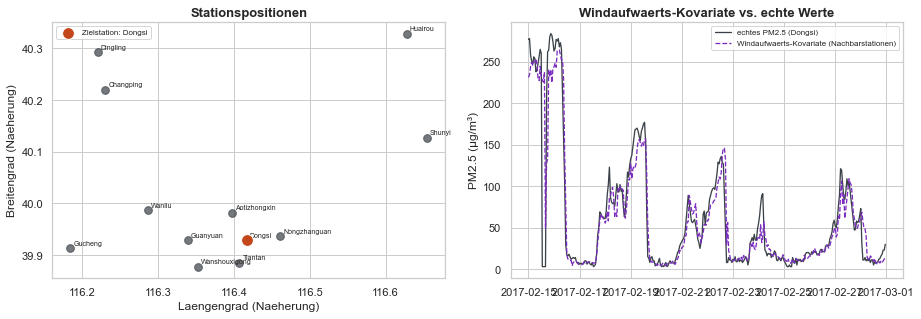

Kennzahlen der neuen Kovariate 'upwind_y':
count    35064.00
mean        80.93
std         78.57
min          3.00
25%         23.56
50%         57.68
75%        109.86
max        746.06
Name: upwind_y, dtype: float64


In [12]:
# --- 6b.3 Kovariate fuer die Beispielstation berechnen und visualisieren ---------------------------
NACHBAR_STATIONEN = [s for s in STATION_KOORDINATEN if s != STATION]
upwind_df = berechne_upwind_kovariate(STATION, NACHBAR_STATIONEN, variante = "basis")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Kartenskizze der Stationen (Naeherungskoordinaten!) mit hervorgehobener Zielstation
lons = [lon for _, lon in STATION_KOORDINATEN.values()]
lats = [lat for lat, _ in STATION_KOORDINATEN.values()]
axes[0].scatter(lons, lats, s=60, color=SLATE, alpha=0.7)
for name, (lat, lon) in STATION_KOORDINATEN.items():
    axes[0].annotate(name, (lon, lat), fontsize=7, xytext=(3, 3), textcoords="offset points")
zlat, zlon = STATION_KOORDINATEN[STATION]
axes[0].scatter([zlon], [zlat], s=140, color=RUST, edgecolor="white", zorder=5,
                label=f"Zielstation: {STATION}")
axes[0].set_xlabel("Laengengrad (Naeherung)"); axes[0].set_ylabel("Breitengrad (Naeherung)")
axes[0].set_title("Stationspositionen"); axes[0].legend(loc="best", fontsize=8)

# echtes PM2.5 vs. Windaufwaerts-Kovariate an der Zielstation, letzte 14 Tage zur Anschauung
g_plot = lade_gesamt("basis", station=STATION)
g_plot = regularize(g_plot, spalten=["y"]).merge(upwind_df, on="ds")
fenster = g_plot.tail(24 * 14)
axes[1].plot(fenster["ds"], fenster["y"], color=SLATE, lw=1.3, label=f"echtes PM2.5 ({STATION})")
axes[1].plot(fenster["ds"], fenster["upwind_y"], color=CHRONOSFARBE, lw=1.3, ls="--",
             label="Windaufwaerts-Kovariate (Nachbarstationen)")
axes[1].set_ylabel("PM2.5 (\u00b5g/m\u00b3)"); axes[1].set_title("Windaufwaerts-Kovariate vs. echte Werte")
axes[1].legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

print("Kennzahlen der neuen Kovariate 'upwind_y':")
print(upwind_df["upwind_y"].describe().round(2))


Station: Dongsi  |  Split-Datum: 2016-12-15

                                               Variante    MAE   RMSE  MASE  MAPE %
     ohne Stationsposition/Wind (bisherige Regressoren) 54.368 94.170 0.923  61.111
            mit Stationsposition/Wind, roh (+ upwind_y) 54.235 94.170 0.921  60.237
mit Stationsposition/Wind, Anomalie (+ upwind_anomalie) 54.054 94.124 0.918  59.589


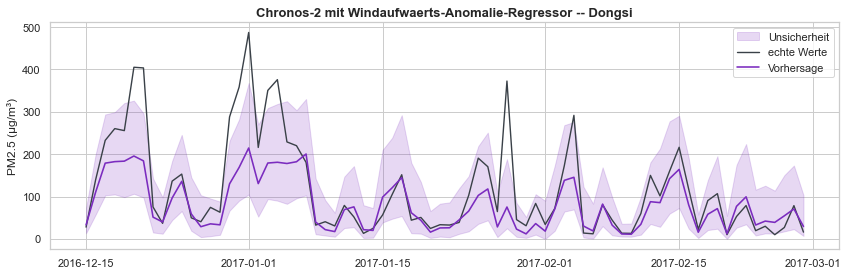

In [13]:
# --- 6b.4 Mini-Ablation: verbessert der Windaufwaerts-Regressor die Prognose? -----------------------
# Analog zur Ablation im Paper (Abschnitt "Assessing the impact of the embedding layer", Fig. 12)
# vergleichen wir hier DREI Varianten, sonst identische Konfiguration (behandelte Daten, Feiertage,
# bestehende Wetter-Regressoren, kein Log): ohne raeumliche Kovariate, mit der rohen Windaufwaerts-
# Konzentration (upwind_y) und mit der Anomalie-Variante (upwind_anomalie, siehe 6b.5-Diagnose) --
# letztere entfernt den dominanten gemeinsamen Peking-weiten Trend und behaelt nur die windgetriebene
# ABWEICHUNG davon. Fehlermasse werden -- wie im Rest des Notebooks -- auf der gemeinsamen
# SKALA_CHRONOS berechnet.

gesamt_geo = lade_gesamt("basis", station=STATION).merge(upwind_df, on="ds", how="left")
gesamt_geo["upwind_y"] = gesamt_geo["upwind_y"].ffill().bfill()
gesamt_geo["upwind_anomalie"] = gesamt_geo["upwind_anomalie"].ffill().bfill()

out_ohne_geo = chronos_predict(
    gesamt_geo, split_datum=SPLIT_DATUM,
    regressoren_zukunft=REGRESSOREN_ZUKUNFT,
    regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT,
    feiertag=True, log=False, station=STATION,
)
out_mit_geo = chronos_predict(
    gesamt_geo, split_datum=SPLIT_DATUM,
    regressoren_zukunft=REGRESSOREN_ZUKUNFT,
    regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT + ["upwind_y"],
    feiertag=True, log=False, station=STATION,
)
out_mit_geo_anomalie = chronos_predict(
    gesamt_geo, split_datum=SPLIT_DATUM,
    regressoren_zukunft=REGRESSOREN_ZUKUNFT,
    regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT + ["upwind_anomalie"],
    feiertag=True, log=False, station=STATION,
)

vergleich_geo = pd.DataFrame([
    {"Variante": "ohne Stationsposition/Wind (bisherige Regressoren)", **jahres_fehler(out_ohne_geo, SKALA_CHRONOS)},
    {"Variante": "mit Stationsposition/Wind, roh (+ upwind_y)",        **jahres_fehler(out_mit_geo, SKALA_CHRONOS)},
    {"Variante": "mit Stationsposition/Wind, Anomalie (+ upwind_anomalie)",
     **jahres_fehler(out_mit_geo_anomalie, SKALA_CHRONOS)},
])
print(f"Station: {STATION}  |  Split-Datum: {SPLIT_DATUM}\n")
print(vergleich_geo.round(3).to_string(index=False))

plot_forecast(out_mit_geo_anomalie, f"Chronos-2 mit Windaufwaerts-Anomalie-Regressor -- {STATION}")


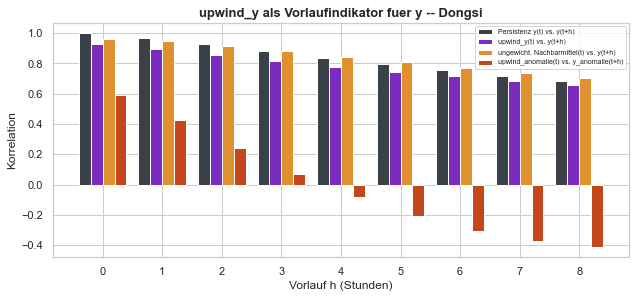

 Vorlauf h (Stunden)  Persistenz y(t) vs. y(t+h)  upwind_y(t) vs. y(t+h)  ungewicht. Nachbarmittel(t) vs. y(t+h)  upwind_anomalie(t) vs. y_anomalie(t+h)
                   0                       1.000                   0.928                                   0.962                                   0.589
                   1                       0.970                   0.895                                   0.947                                   0.428
                   2                       0.926                   0.855                                   0.917                                   0.240
                   3                       0.882                   0.817                                   0.882                                   0.070
                   4                       0.839                   0.780                                   0.846                                  -0.082
                   5                       0.798                   0.746          

In [14]:
# --- 6b.5 Diagnose: traegt upwind_y wirklich ein Lead-Lag-Signal? -----------------------------------
# Kreuzkorrelation zwischen upwind_y(t) und der ZUKUENFTIGEN Zielgroesse y(t+h) fuer h = 0..8 Stunden.
# Ein physikalisch sinnvoller Windaufwaerts-Regressor sollte y(t+h) mindestens so gut (eher besser)
# vorhersagen wie y(t) selbst (h=0) -- sonst enthaelt er kaum Information ueber die eigene Historie
# hinaus. Dient als schneller Sanity-Check der Richtungs-/Geschwindigkeitslogik oben, unabhaengig von
# Chronos-2 (reine Korrelationsrechnung).
#
# ZWEI ZUSAETZLICHE VERGLEICHE, um ein reines "Korreliert stark, aber nicht besser als Persistenz"-
# Ergebnis einzuordnen (typisch fuer stark synoptisch/regional synchronisierte PM2.5-Felder wie Peking):
#   a) UNGEWICHTETER Nachbar-Durchschnitt (kein Richtungs-/Distanz-/Lag-Filter) -- liegt upwind_y nah
#      daran, bringt die ganze Richtungs-/Lag-Logik oben empirisch kaum etwas gegenueber "Mittelwert
#      aller Nachbarn", d. h. der gemeinsame regionale Trend dominiert.
#   b) ANOMALIE-Variante (upwind_y minus eigener lokaler Trend, vs. y(t+h) minus dessen eigenem
#      lokalen Trend) -- prueft, ob NACH Herausrechnen des gemeinsamen Trends noch ein echtes,
#      windgetriebenes Vorlaufsignal in der Restgroesse steckt.
g_diag = lade_gesamt("basis", station=STATION)
g_diag = regularize(g_diag, spalten=["y"]).merge(upwind_df, on="ds", how="left")
g_diag["upwind_y"] = g_diag["upwind_y"].ffill().bfill()
g_diag["upwind_anomalie"] = g_diag["upwind_anomalie"].ffill().bfill()
g_diag["trend_ziel"] = g_diag["y"].rolling(25, center=True, min_periods=1).mean()
g_diag["y_anomalie"] = g_diag["y"] - g_diag["trend_ziel"]

# a) ungewichteter Nachbar-Durchschnitt zum Vergleich
nachbar_werte = []
for nb in NACHBAR_STATIONEN:
    g_nb = regularize(lade_gesamt("basis", station=nb), spalten=["y"]).set_index("ds").reindex(g_diag["ds"])
    nachbar_werte.append(g_nb["y"].to_numpy())
g_diag["nachbar_mittel"] = np.nanmean(np.column_stack(nachbar_werte), axis=1)

korrelationen = []
for h in range(0, 9):
    korrelationen.append({
        "Vorlauf h (Stunden)": h,
        "Persistenz y(t) vs. y(t+h)": g_diag["y"].corr(g_diag["y"].shift(-h)),
        "upwind_y(t) vs. y(t+h)": g_diag["upwind_y"].corr(g_diag["y"].shift(-h)),
        "ungewicht. Nachbarmittel(t) vs. y(t+h)": g_diag["nachbar_mittel"].corr(g_diag["y"].shift(-h)),
        "upwind_anomalie(t) vs. y_anomalie(t+h)": g_diag["upwind_anomalie"].corr(g_diag["y_anomalie"].shift(-h)),
    })
korr_df = pd.DataFrame(korrelationen)

plt.figure(figsize=(9, 4.3))
breite = 0.2
x = np.arange(len(korr_df))
spalten_farben = [("Persistenz y(t) vs. y(t+h)", SLATE), ("upwind_y(t) vs. y(t+h)", CHRONOSFARBE),
                  ("ungewicht. Nachbarmittel(t) vs. y(t+h)", AMBER),
                  ("upwind_anomalie(t) vs. y_anomalie(t+h)", RUST)]
for i_s, (spalte, farbe) in enumerate(spalten_farben):
    plt.bar(x + (i_s - 1.5) * breite, korr_df[spalte], width=breite, label=spalte, color=farbe)
plt.xticks(x, korr_df["Vorlauf h (Stunden)"])
plt.xlabel("Vorlauf h (Stunden)"); plt.ylabel("Korrelation")
plt.title(f"upwind_y als Vorlaufindikator fuer y -- {STATION}")
plt.legend(loc="best", fontsize=7); plt.tight_layout(); plt.show()
print(korr_df.round(3).to_string(index=False))


## 7. Konfigurationsleiter (eine Station, `SPLIT_DATUM` aus Abschnitt 2)

Dieselbe 5-stufige Leiter wie im Prophet-Notebook. Die Regressor-Stufen nutzen automatisch die Auswahl aus
`REGRESSOREN_ZUKUNFT` / `REGRESSOREN_VERGANGENHEIT` (Abschnitt 2).


In [15]:
gesamt_basis_cfg     = lade_gesamt("basis")
gesamt_behandelt_cfg = lade_gesamt("behandelt")

konfigs_chronos = {
    "Basis (univariat)":
        dict(gesamt=gesamt_basis_cfg,     regressoren_zukunft=[], regressoren_vergangenheit=[], feiertag=False, log=False),
    "Basis + Feiertage":
        dict(gesamt=gesamt_basis_cfg,     regressoren_zukunft=[], regressoren_vergangenheit=[], feiertag=True,  log=False),
    "Basis + Feiertage + Regressoren":
        dict(gesamt=gesamt_basis_cfg,     regressoren_zukunft=REGRESSOREN_ZUKUNFT,
             regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT, feiertag=True, log=False),
    "Behandelt + Feiertage + Regressoren":
        dict(gesamt=gesamt_behandelt_cfg, regressoren_zukunft=REGRESSOREN_ZUKUNFT,
             regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT, feiertag=True, log=False),
    "Behandelt + FT + Reg + Log":
        dict(gesamt=gesamt_behandelt_cfg, regressoren_zukunft=REGRESSOREN_ZUKUNFT,
             regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT, feiertag=True, log=True),
}

ergebnisse_chronos = {"Seasonal Naive (Baseline, 4h)": baseline_out_4h}
zeilen = [{"Konfiguration": "Seasonal Naive (Baseline, 4h)", **jahres_fehler(baseline_out_4h, SKALA_CHRONOS)}]

for name, cfg in konfigs_chronos.items():
    out = chronos_predict(cfg["gesamt"], SPLIT_DATUM, regressoren_zukunft=cfg["regressoren_zukunft"],
                          regressoren_vergangenheit=cfg["regressoren_vergangenheit"],
                          feiertag=cfg["feiertag"], log=cfg["log"])
    ergebnisse_chronos[name] = out
    zeilen.append({"Konfiguration": name, **jahres_fehler(out, SKALA_CHRONOS)})
    print(f"fertig: {name}")

metriken_chronos = pd.DataFrame(zeilen)
print(); print(metriken_chronos.round(2).to_string(index=False))


fertig: Basis (univariat)
fertig: Basis + Feiertage
fertig: Basis + Feiertage + Regressoren
fertig: Behandelt + Feiertage + Regressoren
fertig: Behandelt + FT + Reg + Log

                      Konfiguration    MAE   RMSE  MASE  MAPE %
      Seasonal Naive (Baseline, 4h) 103.30 160.07  1.75  101.61
                  Basis (univariat)  95.72 138.87  1.63  222.73
                  Basis + Feiertage  94.86 144.19  1.61  160.48
    Basis + Feiertage + Regressoren  54.37  94.17  0.92   61.11
Behandelt + Feiertage + Regressoren  54.24  93.50  0.92   61.08
         Behandelt + FT + Reg + Log  50.66  87.74  0.86   58.12


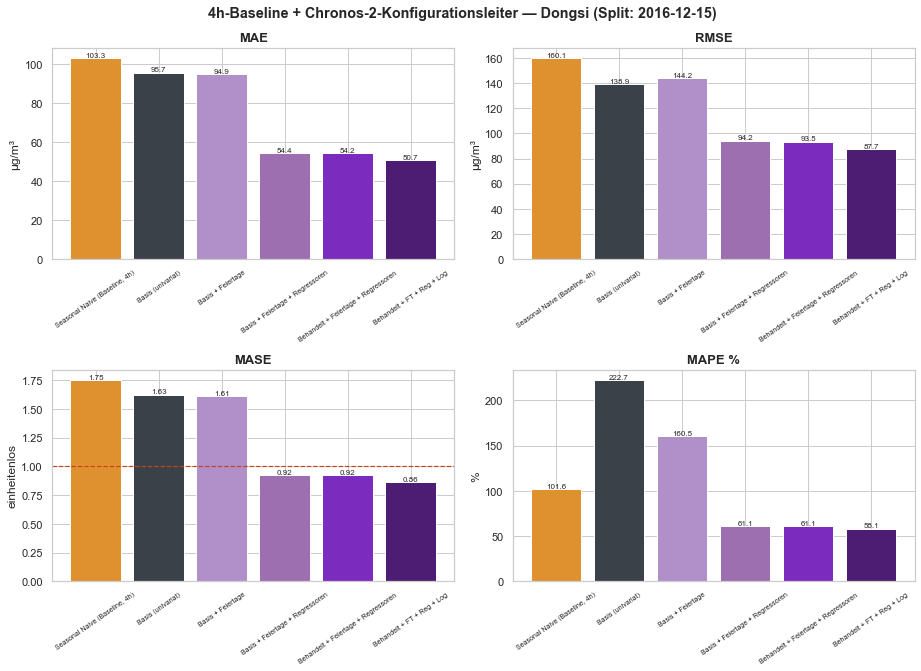

Beste Chronos-2-Konfiguration nach RMSE: Behandelt + FT + Reg + Log


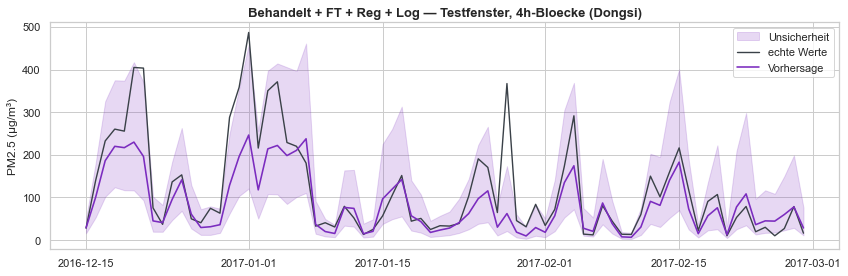

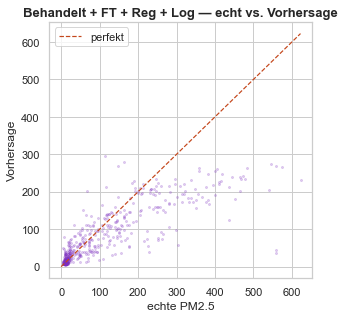

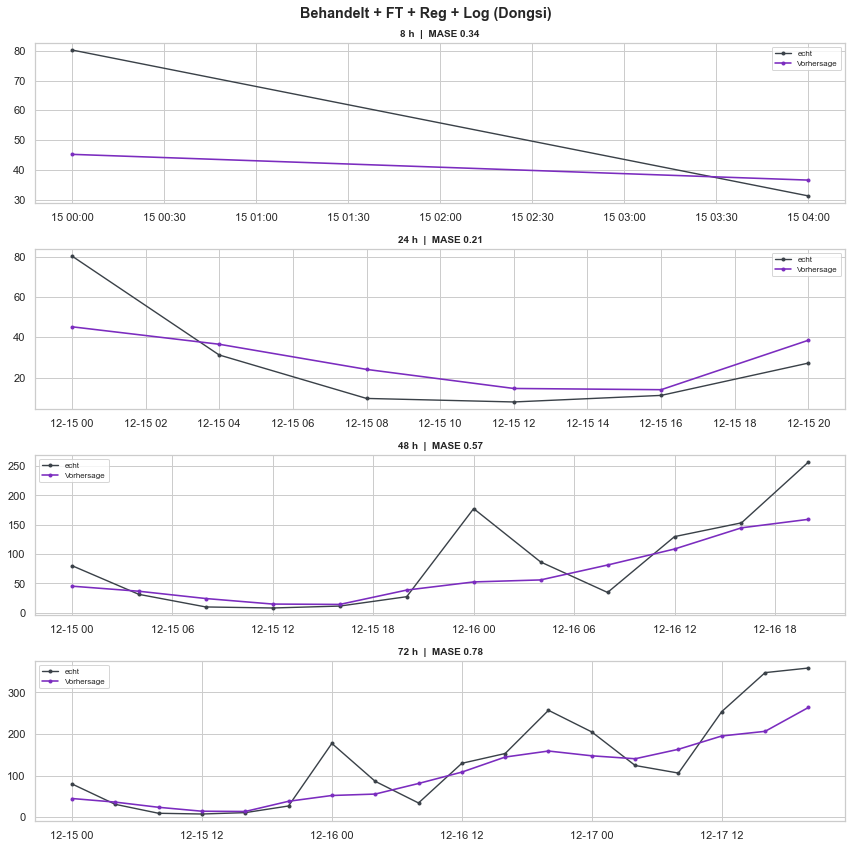

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9.5))
farben = [AMBER, SLATE, "#B18FC9", "#9D6FB0", "#7B2CBF", "#4C1D73"][:len(metriken_chronos)]
einheiten = {"MAE": "µg/m³", "RMSE": "µg/m³", "MASE": "einheitenlos", "MAPE %": "%"}

for ax, metrik in zip(axes.ravel(), ["MAE", "RMSE", "MASE", "MAPE %"]):
    bars = ax.bar(metriken_chronos["Konfiguration"], metriken_chronos[metrik], color=farben)
    ax.set_title(metrik); ax.set_ylabel(einheiten[metrik])
    ax.tick_params(axis="x", rotation=35, labelsize=7)
    fmt = "{:.2f}" if metrik == "MASE" else "{:.1f}"
    for b, v in zip(bars, metriken_chronos[metrik]):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontsize=8)
    if metrik == "MASE":
        ax.axhline(1.0, color=RUST, lw=1.2, ls="--")

plt.suptitle(f"4h-Baseline + Chronos-2-Konfigurationsleiter — {STATION} (Split: {SPLIT_DATUM})", fontweight="bold")
plt.tight_layout(); plt.show()

baseline_namen = ["Seasonal Naive (Baseline, 4h)"]
chronos_only = metriken_chronos[~metriken_chronos["Konfiguration"].isin(baseline_namen)]
best_chronos = chronos_only.sort_values("RMSE").iloc[0]["Konfiguration"]
print("Beste Chronos-2-Konfiguration nach RMSE:", best_chronos)
plot_forecast(ergebnisse_chronos[best_chronos], f"{best_chronos} — Testfenster, 4h-Bloecke ({STATION})")
plot_scatter(ergebnisse_chronos[best_chronos], f"{best_chronos} — echt vs. Vorhersage")
plot_horizonte(ergebnisse_chronos[best_chronos], f"{best_chronos} ({STATION})", SKALA_CHRONOS,
              schritt_stunden=AGG_STUNDEN)


## 8. Split-Datum variieren

Konkrete Anwendung der neuen Flexibilität aus Abschnitt 6: Dieselbe beste Konfiguration aus Abschnitt 7 wird
hier für **mehrere Split-Daten** neu ausgewertet — das zeigt, wie stabil (oder instabil) die Fehlermaße über
verschiedene Trainings-/Testzeiträume hinweg sind. Trainingslänge und Jahreszeit des Testfensters ändern sich
dabei jeweils mit.

> ⏱️ Jeder Split-Punkt ist ein eigener `predict_df`-Aufruf (kein erneutes Training nötig, Chronos-2 ist
> zero-shot) — trotzdem beeinflusst ein früherer Split ein längeres Testfenster (mehr Vorhersageschritte,
> etwas länger in der Berechnung).


In [17]:
SPLIT_DATEN_TEST = ["2016-03-01", "2016-06-01", "2016-09-01", "2016-12-01"]   # frei anpassbar

cfg_best = konfigs_chronos[best_chronos]
zeilen_split = []
for sd in SPLIT_DATEN_TEST:
    out_sd = chronos_predict(cfg_best["gesamt"], sd, regressoren_zukunft=cfg_best["regressoren_zukunft"],
                             regressoren_vergangenheit=cfg_best["regressoren_vergangenheit"],
                             feiertag=cfg_best["feiertag"], log=cfg_best["log"])
    tr_sd, _ = split_bei(cfg_best["gesamt"], sd)
    tr_sd_4h = aggregiere(regularize(tr_sd, spalten=["y"]), AGG_STUNDEN, spalten=["y"])
    skala_sd = mase_skala(tr_sd_4h["y"], m=SAISON_M_CHRONOS)
    zeilen_split.append({"Split-Datum": sd, "Trainingslaenge (Tage)": (pd.Timestamp(sd) - tr_sd["ds"].min()).days,
                         **jahres_fehler(out_sd, skala_sd)})
    print(f"fertig: Split {sd}")

vergleich_split = pd.DataFrame(zeilen_split)
print(); print(vergleich_split.round(2).to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.bar(vergleich_split["Split-Datum"], vergleich_split["MASE"], color=CHRONOSFARBE)
plt.axhline(1.0, color=RUST, lw=1.2, ls="--", label="Baseline-Niveau (MASE = 1)")
plt.ylabel("MASE"); plt.title(f"{best_chronos} — MASE ueber verschiedene Split-Daten ({STATION})")
plt.legend(loc="best"); plt.tight_layout(); plt.show()


KeyboardInterrupt: 

## 9. Finale multivariate Prognose: alle Stationen + Feiertage + Regressoren + Log

Der letzte Schritt kombiniert alles: **behandelte Daten**, **Feiertage**, die gewählten **Regressoren**
(mit Zukunfts-/Vergangenheits-Unterscheidung aus Abschnitt 2) und **Log-Ziel** — jetzt aber **multivariat**
über bis zu 12 Stationen gleichzeitig, statt pro Station einzeln. Chronos-2 übergeben wir dazu die Zielreihen
aller Stationen **gemeinsam** (`target=<Liste der Stationsnamen>`), sodass die eingebaute Group-Attention
Abhängigkeiten zwischen den Stationen nutzen kann (ähnliches Wetter, gemeinsame Smog-Ausbreitung über die
Stadt).

**Regressoren im multivariaten Fall:** Wetterregressoren sind eigentlich stationsspezifisch. Um das Beispiel
handhabbar zu halten, verwenden wir hier den **Stadt-Mittelwert** je gewähltem Regressor über alle Stationen als
gemeinsame Kovariate (statt 12 separater, stationsspezifischer Spalten) — das ist eine bewusste Vereinfachung.

> ⚠️ **Format-Hinweis (wie im vorherigen Notebook):** Das exakte Rückgabeformat von `predict_df()` für
> multivariate Ziele kann je nach `chronos-forecasting`-Version variieren (Wide- oder Long-Format).
> `extrahiere_multivariate_vorhersage()` prüft beide gängigen Varianten und meldet sich mit einer klaren
> Fehlermeldung inkl. `pred_df.columns`, falls keine davon passt.
>
> ⚠️ **Stationsspezifische statt gemittelte Regressoren:** Wer echte, stationsspezifische Kovariaten im
> multivariaten Fall braucht, müsste pro Station eigene, eindeutig benannte Spalten (z. B.
> `TEMP_Aotizhongxin`) anlegen und gegen die genaue Kovariaten-Schnittstelle der eigenen
> `chronos-forecasting`-Version prüfen — das war in dieser Umgebung ohne Zugriff auf die Bibliothek nicht
> verifizierbar.


In [18]:
STATIONEN_MULTIVARIATE = sorted(p.name.replace("chronos_", "").replace(".csv", "")
                                for p in (PREP / "basis").glob("chronos_*.csv"))[:12]
VARIANTE_MV = "behandelt"
FEIERTAG_MV = True
LOG_MV = True
KONTEXT_TAGE_MV = None             # z.B. 180 setzen, falls die volle Historie zu lang fuer den Kontext ist

print(f"{len(STATIONEN_MULTIVARIATE)} Station(en) fuer die multivariate Prognose: {STATIONEN_MULTIVARIATE}")

# jede Station laden, am SPLIT_DATUM trennen, regularisieren, auf 4h aggregieren, dann im WIDE-Format
# zusammenfuehren (eine Zielspalte je Station + eine gemeinsame, stadtgemittelte Spalte je Regressor)
train_teile, test_teile, train_reg_teile, test_reg_teile = [], [], {r: [] for r in REGRESSOREN_ZUKUNFT + REGRESSOREN_VERGANGENHEIT}, {r: [] for r in REGRESSOREN_ZUKUNFT}
alle_regressoren_mv = REGRESSOREN_ZUKUNFT + REGRESSOREN_VERGANGENHEIT

for st in STATIONEN_MULTIVARIATE:
    g_st = lade_gesamt(VARIANTE_MV, station=st)
    # ERST auf der GESAMTEN Reihe regularisieren+aggregieren, DANN am Split-Datum trennen -- sonst kann
    # am Uebergang ein Bruch im 4h-Raster entstehen (siehe chronos_predict() in Abschnitt 6).
    g_reg = aggregiere(regularize(g_st, spalten=["y"] + alle_regressoren_mv), AGG_STUNDEN,
                       spalten=["y"] + alle_regressoren_mv)
    tr_st, te_st = split_bei(g_reg, SPLIT_DATUM)   # dieselbe (korrigierte) Split-Logik wie in chronos_predict()
    train_teile.append(tr_st.set_index("ds")[["y"]].rename(columns={"y": st}))
    test_teile.append(te_st.set_index("ds")[["y"]].rename(columns={"y": st}))
    for r in alle_regressoren_mv:
        train_reg_teile[r].append(tr_st.set_index("ds")[[r]])
    for r in REGRESSOREN_ZUKUNFT:
        test_reg_teile[r].append(te_st.set_index("ds")[[r]])

train_wide = pd.concat(train_teile, axis=1)
test_wide  = pd.concat(test_teile,  axis=1)

# Absicherung: jede Station wurde auf ihrem EIGENEN Min/Max-Zeitraum regularisiert -- falls einzelne
# Stationen einen (leicht) abweichenden Datenzeitraum haben, entstehen beim Zusammenfuehren NaNs.
# Fuer die multivariate Zielreihe droppen wir solche Zeilen (Chronos-2 braucht vollstaendige Ziele).
n_vorher = len(train_wide)
train_wide = train_wide.dropna(subset=STATIONEN_MULTIVARIATE)
if len(train_wide) < n_vorher:
    print(f"Hinweis: {n_vorher - len(train_wide)} Trainingszeilen wegen abweichender Stations-Zeitraeume "
          f"entfernt (von {n_vorher}).")

# Stadt-Mittelwert je Regressor (siehe Hinweis oben) als gemeinsame Kovariate ergaenzen
for r in alle_regressoren_mv:
    train_wide[r] = pd.concat(train_reg_teile[r], axis=1).mean(axis=1)
for r in REGRESSOREN_ZUKUNFT:
    test_wide[r] = pd.concat(test_reg_teile[r], axis=1).mean(axis=1)

train_wide = train_wide.reset_index(); test_wide = test_wide.reset_index()
if FEIERTAG_MV:
    train_wide = add_feiertag(train_wide)
    test_wide  = add_feiertag(test_wide)
if KONTEXT_TAGE_MV:
    train_wide = train_wide.tail(int(KONTEXT_TAGE_MV * 24 / AGG_STUNDEN)).reset_index(drop=True)
if LOG_MV:
    for st in STATIONEN_MULTIVARIATE:
        train_wide[st] = np.log1p(train_wide[st])

# Chronos-2s Kontext-Limit: wenn `context_length` nicht explizit gesetzt wird (wie hier), verwendet
# predict_df() automatisch das Modell-Maximum (8192 Zeitschritte je Serie). Ist unser Kontext laenger,
# wuerde intern STILLSCHWEIGEND auf die letzten 8192 Schritte gekuerzt -- aeltere Historie ginge verloren.
CHRONOS_MAX_KONTEXT = 8192
auslastung = len(train_wide) / CHRONOS_MAX_KONTEXT
print(f"{len(train_wide)} Trainings- / {len(test_wide)} Test-4h-Bloecke (Split: {SPLIT_DATUM})")
print(f"Kontext-Auslastung: {len(train_wide)} / {CHRONOS_MAX_KONTEXT} Schritte ({auslastung:.0%}) "
      f"-- {'volle Historie wird genutzt, keine Kuerzung' if auslastung <= 1 else 'ACHTUNG: wird auf die letzten ' + str(CHRONOS_MAX_KONTEXT) + ' Schritte gekuerzt!'}")
stunden_gesamt = len(train_wide) * AGG_STUNDEN
if stunden_gesamt > CHRONOS_MAX_KONTEXT:   # zur Einordnung: waere bei AGG_STUNDEN=1 (stuendlich) ueber dem Limit?
    print(f"Hinweis: bei AGG_STUNDEN=1 (stuendliche Aufloesung) waeren das {stunden_gesamt} Schritte -- "
          f"ueber dem Chronos-2-Limit ({CHRONOS_MAX_KONTEXT}), es wuerde also auf die letzten "
          f"{CHRONOS_MAX_KONTEXT} Stunden (~{CHRONOS_MAX_KONTEXT // 24} Tage) gekuerzt. Die 4h-Aggregation "
          f"erlaubt hier, mehr Historie im Kontextfenster unterzubringen.")


12 Station(en) fuer die multivariate Prognose: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
8310 Trainings- / 456 Test-4h-Bloecke (Split: 2016-12-15)
Kontext-Auslastung: 8310 / 8192 Schritte (101%) -- ACHTUNG: wird auf die letzten 8192 Schritte gekuerzt!
Hinweis: bei AGG_STUNDEN=1 (stuendliche Aufloesung) waeren das 33240 Schritte -- ueber dem Chronos-2-Limit (8192), es wuerde also auf die letzten 8192 Stunden (~341 Tage) gekuerzt. Die 4h-Aggregation erlaubt hier, mehr Historie im Kontextfenster unterzubringen.


In [19]:
alle_kov_mv    = alle_regressoren_mv + (["feiertag"] if FEIERTAG_MV else [])
zukunft_kov_mv = REGRESSOREN_ZUKUNFT   + (["feiertag"] if FEIERTAG_MV else [])

context_df = train_wide[["ds"] + STATIONEN_MULTIVARIATE + alle_kov_mv].copy()
context_df["id"] = "alle_stationen"
future_df = test_wide[["ds"] + zukunft_kov_mv].copy()
future_df["id"] = "alle_stationen"

pred_df = chronos_pipeline.predict_df(
    context_df, future_df=future_df,
    prediction_length=len(test_wide),
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="id", timestamp_column="ds", target=STATIONEN_MULTIVARIATE,   # Liste = multivariate Prognose
    freq=FREQ_CHRONOS,
    context_length=CHRONOS_MAX_KONTEXT,   # explizit statt implizit auf den Default verlassen (siehe Hinweis oben)
)
print("Spalten der Rueckgabe (zur Kontrolle des Formats):", list(pred_df.columns))


Spalten der Rueckgabe (zur Kontrolle des Formats): ['id', 'ds', 'target_name', 'predictions', '0.1', '0.5', '0.9']


In [20]:
def extrahiere_multivariate_vorhersage(pred_df, stationen, quantil="0.5"):
    '''Passt sich an das von predict_df() zurueckgegebene Format fuer Multivariate-Vorhersagen an.
    Prueft ein WIDE-Format (eine Spalte je Station) und ein LONG-Format (eine Spalte unterscheidet die
    Ziele je Zeile). Gibt ein dict {station: DataFrame(ds, yhat)} zurueck.'''
    if all(st in pred_df.columns for st in stationen):                 # Fall 1: WIDE-Format
        return {st: pred_df[["ds", st]].rename(columns={st: "yhat"}) for st in stationen}

    # Fall 2: LONG-Format -- Kandidaten-Spalten in der Reihenfolge, wie wahrscheinlich sie
    # tatsaechlich die STATIONSNAMEN je Ziel tragen. "id" bewusst zuletzt: wir haben id_column
    # selbst mit dem KONSTANTEN Gruppennamen "alle_stationen" befuellt (eine Gruppe = alle Ziele
    # gemeinsam) -- diese Spalte kann die einzelnen Ziele also gar nicht unterscheiden.
    if quantil in pred_df.columns:
        for id_spalte in [c for c in ["target_name", "target", "item_id", "id"] if c in pred_df.columns]:
            werte = set(pred_df[id_spalte].unique())
            if set(stationen) <= werte:   # nur akzeptieren, wenn diese Spalte WIRKLICH alle Stationen enthaelt
                return {st: pred_df[pred_df[id_spalte] == st][["ds", quantil]].rename(columns={quantil: "yhat"})
                       for st in stationen}

    raise ValueError(
        "Format von pred_df nicht erkannt -- keine Spalte enthaelt alle Stationsnamen als Werte "
        "(die Spalte 'id' ist hier absichtlich ausgeschlossen, siehe Docstring). Bitte pred_df.head() "
        f"pruefen und diese Funktion anpassen. Gefundene Spalten: {list(pred_df.columns)}"
    )

vorhersagen_mv = extrahiere_multivariate_vorhersage(pred_df, STATIONEN_MULTIVARIATE)
leer = [st for st, df_st in vorhersagen_mv.items() if len(df_st) == 0]
if leer:
    raise ValueError(
        f"Vorhersage fuer {len(leer)} Station(en) ist leer: {leer}. Das deutet auf ein falsch erkanntes "
        "pred_df-Format hin -- bitte pred_df.head() und extrahiere_multivariate_vorhersage() pruefen."
    )
rueck_mv = (lambda a: np.expm1(a)) if LOG_MV else (lambda a: a)

resultate_mv, out_je_station_mv = [], []
for st in STATIONEN_MULTIVARIATE:
    g_basis_st = lade_gesamt("basis", station=st)
    tr_basis_st, _ = split_bei(g_basis_st, SPLIT_DATUM)
    tr_basis_st_4h = aggregiere(regularize(tr_basis_st, spalten=["y"]), AGG_STUNDEN, spalten=["y"])
    skala_st = mase_skala(tr_basis_st_4h["y"], m=SAISON_M_CHRONOS)

    g_mv_st = lade_gesamt(VARIANTE_MV, station=st)
    _, te_original_st = split_bei(g_mv_st, SPLIT_DATUM)
    te_original_4h = (te_original_st.set_index("ds")[["y"]].resample(f"{AGG_STUNDEN}h").mean()
                      .dropna().reset_index())

    pred_st = vorhersagen_mv[st].copy()
    pred_st["yhat"] = rueck_mv(pred_st["yhat"]).clip(lower=0)
    out_st = te_original_4h.merge(pred_st, on="ds")   # nur echte (nicht interpolierte) 4h-Bloecke
    resultate_mv.append({"Station": st, **jahres_fehler(out_st, skala_st)})
    out_je_station_mv.append(out_st)

metriken_mv = pd.DataFrame(resultate_mv)
print("Multivariate Prognose -- Fehlermasse je Station (4h-Bloecke):")
print(metriken_mv.round(2).to_string(index=False))
print()
print("Durchschnitt ueber alle Stationen (multivariat):")
print(metriken_mv[["MAE", "RMSE", "MASE", "MAPE %"]].mean().round(2).to_string())


Multivariate Prognose -- Fehlermasse je Station (4h-Bloecke):
      Station   MAE  RMSE  MASE  MAPE %
 Aotizhongxin 45.54 78.77  0.81   55.70
    Changping 35.26 66.24  0.71   47.81
     Dingling 32.49 58.06  0.65   53.98
       Dongsi 53.78 92.74  0.91   59.08
     Guanyuan 48.60 83.67  0.88   55.74
      Gucheng 50.28 92.26  0.91   59.47
      Huairou 34.87 63.86  0.71   52.41
 Nongzhanguan 51.52 86.16  0.87   59.62
       Shunyi 44.71 80.61  0.80   55.10
      Tiantan 51.91 86.63  0.93   57.76
       Wanliu 45.01 79.59  0.80   60.56
Wanshouxigong 57.55 97.48  0.99   64.73

Durchschnitt ueber alle Stationen (multivariat):
MAE       45.96
RMSE      80.51
MASE       0.83
MAPE %    56.83


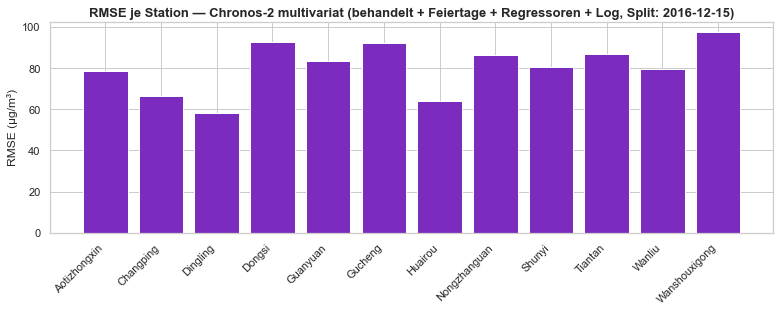

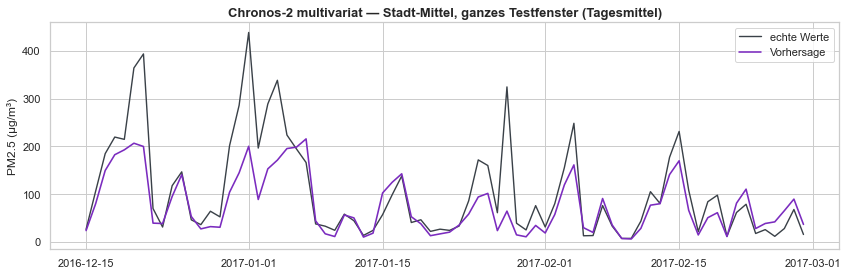

In [21]:
plt.figure(figsize=(11, 4.5))
plt.bar(metriken_mv["Station"], metriken_mv["RMSE"], color=CHRONOSFARBE)
plt.ylabel("RMSE (µg/m³)")
plt.title(f"RMSE je Station — Chronos-2 multivariat (behandelt + Feiertage + Regressoren + Log, Split: {SPLIT_DATUM})")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

# Stadt-Mittel: echte Werte vs. multivariate Vorhersage, Tagesmittel ueber das Testfenster
stadt_mv = (pd.concat(out_je_station_mv, ignore_index=True)
              .groupby("ds")[["y", "yhat"]].mean().reset_index())
plot_forecast(stadt_mv, "Chronos-2 multivariat — Stadt-Mittel, ganzes Testfenster (Tagesmittel)")


## 10. Interaktives Dashboard: Chronos-2 vs. Seasonal Naive

Ein Dashboard (`ipywidgets`) zum **explorativen** Durchspielen der wichtigsten Stellschrauben, **nur** für den
direkten Vergleich Chronos-2 gegen die Seasonal-Naive-Baseline (keine Konfigurationsleiter, kein Multivariate —
dafür schnell iterierbar):

- **Split-Datum** — wie in Abschnitt 6/8.
- **Aggregationsstunden** — 1 (stündlich) bis 24 (täglich); bestimmt auch die Seasonal-Naive-Periode `m`
  automatisch mit (`m = 24 / Aggregationsstunden`, mindestens 1).
- **Vorhersagehorizont in Tagen** — anders als bisher wird der Test hier **nicht** bis zum Ende der Daten
  vorhergesagt, sondern nur für die gewählte Anzahl Tage ab dem Split-Datum.
- **Feiertage, Regressoren, Log** — dieselben Bausteine wie in der Konfigurationsleiter (Abschnitt 7), hier per
  Checkbox/Mehrfachauswahl statt fest codiert. Die Zukunfts-/Vergangenheits-Einordnung der gewählten Regressoren
  übernimmt weiterhin `REGRESSOREN_ZUKUNFT`/`REGRESSOREN_VERGANGENHEIT` aus Abschnitt 2.
- **Stationen** — Mehrfachauswahl; für jede gewählte Station gibt es eine eigene Zeile in der Ergebnistabelle
  und einen eigenen Plot.
- **Rauschen glätten (optional)** — ein leichter gleitender Mittelwert **nur auf den Trainingsdaten** (nicht auf
  den Testdaten, sonst würde das Ergebnis geschönt). Das ist eine leichtgewichtige Alternative zur festen
  `behandelt`-Ausreißerkappung aus den anderen Notebooks — hier direkt im Dashboard einstellbar, ohne von
  Kapitel 03 abhängig zu sein.

> ⏱️ Jeder Klick auf **Berechnen** ist reine Inferenz (kein Training) — auch bei mehreren Stationen meist
> Sekunden bis wenige Minuten, abhängig von Hardware und Anzahl gewählter Stationen.


## 12. Erweitertes interaktives Dashboard: räumliche Kovariate, Normierung, Regressor-Modus je Variable & Konfidenzintervall

Zusätzlich zum Dashboard aus Abschnitt 10 hier ein zweites, das genau die Stellschrauben abdeckt, die für
die Frage "warum bringt die räumliche Modellierung (Abschnitt 6b) kaum etwas?" relevant sind. Gegenüber der
ersten Fassung dieses Abschnitts neu:

- **Regressor-Modus JE Variable** — statt einer globalen Umschaltung "alle historisch" vs. "alle zukünftig"
  lässt sich jetzt für jeden Regressor einzeln an-/abwählen und einzeln festlegen, ob er nur als
  Vergangenheits-Kontext dient oder auch für den Prognosezeitraum als bekannt gilt (`future_df`). So lässt
  sich z. B. "Temperatur zukünftig bekannt, aber Luftschadstoffe nur historisch" realistisch abbilden.
  `upwind_y` (räumliche Kovariate) bleibt IMMER Vergangenheits-Kontext, da er aus bereits gemessenen
  Nachbarwerten gebaut wird und operativ nicht im Voraus bekannt sein kann.
- **Prognosehorizont in Stunden** (statt Tagen) — direkt eintippbar, für kurze (z. B. 24h) und lange (z. B.
  mehrere Monate) Testfenster gleichermaßen geeignet.
- **80 %-Konfidenzintervall im Plot** — Chronos-2 liefert ohnehin die Quantile 0.1/0.5/0.9; das 10%-90%-Band
  (= 80 % Prognoseintervall) wird jetzt zusätzlich zur Punktprognose eingezeichnet.
- **Räumliche Koordinaten (ja/nein)** — schaltet den überarbeiteten `upwind_y`-Regressor aus Abschnitt 6b
  ein/aus (siehe dortige Überarbeitung: windgeschwindigkeitsabhängiger Zeitversatz statt fester Annahme,
  Distanzabfall, kein richtungsloser Gewichtssockel mehr — plus Diagnose-Zelle 6b.5 zur Prüfung des
  Lead-Lag-Signals).
- **Normieren (ja/nein)** — z-Score-Normierung der Zielgröße, ausschließlich auf den Trainingsdaten geschätzt
  (Mittelwert/Std.) und danach zurücktransformiert — kein Leakage. Kombinierbar mit Logarithmieren.
- **Mehrere Stationen gleichzeitig** — inkl. MASE-Vergleichsbalken je Station.
- **Neu: Variante (`basis` / `behandelt`)** — wählbar wie in Abschnitt 9. ⚠️ Bei `behandelt` gilt derselbe
  Warnhinweis wie in Abschnitt 2: die Ausreißerkappung ist auf den ursprünglichen Kapitel-03-Split (1.3.2016)
  fixiert und wird hier NICHT für ein neues `Split-Datum` neu berechnet — bei stark abweichendem Split kann
  die Kappungsgrenze daher etwas verzerrt im Test- statt Trainingszeitraum liegen. Für die meisten explorativen
  Vergleiche unkritisch, für eine exakte finale Bewertung mit stark verschobenem Split lieber `basis` nutzen.
- **Neu: Saisonalitäts-Kovariaten** (`tage_seit_cny`, `cny_naehe`, `jahr_sin`, `jahr_cos`, siehe Abschnitt 2)
  stehen jetzt ebenfalls in der Regressor-Liste zur Auswahl. Anders als das binäre `feiertag`-Flag (nur die
  amtlichen Feiertage selbst) bilden sie den graduellen Verlauf um Chinesisch Neujahr sowie die generelle
  Winter-/Heizsaison explizit und kontinuierlich ab — siehe Diagnose weiter unten (6c).

> ⚠️ **Stolperfalle bei Chinesisch Neujahr:** Der Default-Horizont ist unten bewusst auf 60 Tage gesetzt.
> Mit dem Standard-`SPLIT_DATUM` (15.12.2016) und dem *alten* Default von 14 Tagen endete das Testfenster am
> 29.12.2016 — CNY 2017 (28.01.2017) lag also außerhalb des Testfensters und tauchte im Dashboard nie auf,
> unabhängig von der Modellgüte. Bei eigenen Läufen immer prüfen: `Split-Datum + Horizont` muss über das
> gewünschte CNY-Datum hinausreichen (siehe `CNY_TERMINE` in Abschnitt 2 für die exakten Daten je Jahr).


In [22]:
def normiere_transformiere(tr, te, log, normieren):
    '''Wendet optional log1p und/oder z-Score-Normierung auf die Zielgroesse an -- Mittelwert/Std werden
    NUR auf den Trainingsdaten geschaetzt (kein Leakage aus dem Testfenster). Gibt (tr_transformiert,
    rueck_transform_funktion) zurueck; rueck_transform_funktion macht beide Schritte in der richtigen
    Reihenfolge rueckgaengig (erst Normierung, dann log) und schneidet bei 0 ab (PM2.5 >= 0). Da beide
    Transformationen streng monoton steigend sind, bleibt die Quantil-Reihenfolge erhalten -- die
    Funktion kann daher unveraendert auch auf die 10%-/90%-Quantile (Konfidenzintervall) angewendet werden.'''
    tr_t = tr.copy()
    mean_, std_ = 0.0, 1.0
    if log:
        tr_t["y"] = np.log1p(tr_t["y"])
    if normieren:
        mean_, std_ = float(tr_t["y"].mean()), float(tr_t["y"].std())
        if std_ == 0 or np.isnan(std_):
            std_ = 1.0
        tr_t["y"] = (tr_t["y"] - mean_) / std_

    def rueck(a):
        a = np.asarray(a, dtype=float)
        if normieren:
            a = a * std_ + mean_
        if log:
            a = np.expm1(a)
        return np.clip(a, 0, None)

    return tr_t, rueck


def dashboard_lauf_v2(station, variante, split_datum, agg_stunden, horizont_stunden, feiertag,
                      regressor_konfiguration, raeumlich_modus, log, normieren, glaetten, glaettung_fenster):
    '''Erweiterte Variante von dashboard_lauf() (Abschnitt 10): raeumliche Kovariate (upwind_y /
    upwind_anomalie, Abschnitt 6b), Normierung, Horizont in STUNDEN, 80%-Konfidenzintervall UND je
    Regressor einzeln waehlbarer Modus (nur historisch vs. auch zukuenftig bekannt) -- statt der festen
    Aufteilung aus REGRESSOREN_ZUKUNFT/REGRESSOREN_VERGANGENHEIT (Abschnitt 2) oder eines globalen
    Umschalters.

    variante: "basis" | "behandelt" -- welche vorbereitete CSV-Variante geladen wird (siehe Abschnitt 9:
    "behandelt" enthaelt zusaetzliche Datenaufbereitungsschritte gegenueber "basis"; Achtung beim Vergleich
    ueber verschiedene Split-Daten, siehe Warnhinweis zur festen Kapitel-03-Kappung oben in Abschnitt 2).

    regressor_konfiguration: dict {regressorname: "historisch" | "zukuenftig bekannt"} -- enthaelt NUR
    die aktiven (angehakten) Regressoren; die raeumliche Kovariate wird hier bewusst NICHT hineingemischt,
    sondern unten separat und immer als "historisch" behandelt.

    raeumlich_modus: "aus" | "roh (upwind_y)" | "Anomalie (upwind_anomalie)" -- siehe Diagnose-Zelle 6b.5:
    die rohe Windaufwaerts-Konzentration korreliert kaum staerker mit der Zukunft als reine Persistenz
    (dominanter gemeinsamer Peking-Trend), die Anomalie-Variante entfernt diesen Trend und behaelt nur
    die windgetriebene Abweichung -- daher beide Varianten zum Vergleich waehlbar.'''
    saison_m_dyn = max(1, round(SAISON_M / agg_stunden))

    gesamt = lade_gesamt(variante, station=station)

    alle_regressoren_ausw = list(regressor_konfiguration.keys())
    if raeumlich_modus != "aus":
        nachbarn = [s for s in STATION_KOORDINATEN if s != station]
        upwind_df = berechne_upwind_kovariate(station, nachbarn, variante=variante)
        gesamt = gesamt.merge(upwind_df, on="ds", how="left")
        raeumliche_spalte = "upwind_y" if raeumlich_modus.startswith("roh") else "upwind_anomalie"
        gesamt[raeumliche_spalte] = gesamt[raeumliche_spalte].ffill().bfill()
        alle_regressoren_ausw = alle_regressoren_ausw + [raeumliche_spalte]

    g = regularize(gesamt, spalten=["y"] + alle_regressoren_ausw)
    tr, te = split_bei(g, split_datum)                              # noch stuendlich

    horizont_ende = pd.Timestamp(split_datum) + pd.Timedelta(hours=horizont_stunden)
    te = te[te["ds"] < horizont_ende].reset_index(drop=True)        # Test auf den Horizont kappen

    if glaetten:
        tr = glaette_trainingsrauschen(tr, glaettung_fenster)       # NUR Training, NIE Test

    if agg_stunden and agg_stunden > 1:
        tr = aggregiere(tr, agg_stunden, spalten=["y"] + alle_regressoren_ausw)
        te = aggregiere(te, agg_stunden, spalten=["y"] + alle_regressoren_ausw)

    # Skala fuer MASE auf der UNVERAENDERTEN (nicht log/normierten) Reihe -- bleibt so vergleichbar
    # mit den anderen Abschnitten des Notebooks.
    skala = mase_skala(tr["y"], m=saison_m_dyn)
    out_naive = seasonal_naive(tr, te, m=saison_m_dyn)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)

    # Regressor-Modus JE Variable: alles, was in regressor_konfiguration auf "zukuenftig bekannt" steht,
    # geht in future_df; alles andere (inkl. der raeumlichen Kovariate, IMMER) nur in context_df.
    regressoren_zukunft_ausw = [r for r, modus in regressor_konfiguration.items()
                                if modus == "zukuenftig bekannt"]
    zukunft_kov = regressoren_zukunft_ausw + (["feiertag"] if feiertag else [])
    alle_kov    = alle_regressoren_ausw + (["feiertag"] if feiertag else [])

    tr_c, rueck = normiere_transformiere(tr, te, log=log, normieren=normieren)
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df,
        prediction_length=len(te),
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id", timestamp_column="ds", target="target",
        freq=f"{agg_stunden}h" if agg_stunden and agg_stunden > 1 else FREQ,
    )
    pred_df = pred_df.rename(columns={"0.5": "yhat", "0.1": "yhat_lower", "0.9": "yhat_upper"})
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        pred_df[c] = rueck(pred_df[c])   # monoton -> Quantil-Reihenfolge bleibt beim Rueck-Transform erhalten

    # Auswertung gegen die ECHTEN (nicht interpolierten) Testwerte im gewaehlten Horizont
    _, te_original = split_bei(gesamt, split_datum)
    te_original = te_original[te_original["ds"] < horizont_ende]
    if agg_stunden and agg_stunden > 1:
        te_eval = (te_original.set_index("ds")[["y"]].resample(f"{agg_stunden}h").mean()
                  .dropna().rename_axis("ds").reset_index())
    else:
        te_eval = te_original[["ds", "y"]].reset_index(drop=True)

    out_chronos = te_eval.merge(pred_df[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    return out_chronos, out_naive, skala


In [26]:
# --- Widgets (erweitertes Dashboard) ----------------------------------------------------------------
# Stationsliste konsistent zur Namenskonvention aus lade_gesamt() (chronos_{station}.csv) bilden --
# NICHT das prophet_train_*.csv-Muster aus Abschnitt 9/10, das im aktuellen prepared_chronos-Ordner
# nicht mehr existiert. Zur Sicherheit STATION ergaenzen, falls sie aus irgendeinem Grund fehlt.
alle_stationen_dash2 = sorted(p.name.replace("chronos_", "").replace(".csv", "")
                              for p in (PREP / "basis").glob("chronos_*.csv"))
if STATION not in alle_stationen_dash2:
    alle_stationen_dash2 = sorted(set(alle_stationen_dash2) | {STATION})

w2_split      = widgets.DatePicker(description="Split-Datum:", value=pd.Timestamp(SPLIT_DATUM).date())
w2_variante   = widgets.Dropdown(description="Variante:", options=["basis", "behandelt"],
                                 value="basis", style={"description_width": "initial"})
w2_agg        = widgets.Dropdown(description="Aggregation (h):", options=[1, 2, 3, 4, 6, 8, 12, 24], value=AGG_STUNDEN)
w2_horizont   = widgets.BoundedIntText(description="Horizont (Stunden):", min=1, max=24 * 365, step=1,
                                       value=24 * 60, style={"description_width": "initial"})
w2_feiertag   = widgets.Checkbox(description="Feiertage", value=True)
w2_raeumlich  = widgets.Dropdown(description="Raeumliche Kovariate:",
                                 options=["aus", "roh (upwind_y)", "Anomalie (upwind_anomalie)"],
                                 value="aus", style={"description_width": "initial"})
w2_log        = widgets.Checkbox(description="Log-Ziel", value=False)
w2_norm       = widgets.Checkbox(description="Normieren (z-Score)", value=False)
w2_stationen  = widgets.SelectMultiple(description="Stationen:", options=alle_stationen_dash2,
                                       value=(STATION,), rows=min(8, len(alle_stationen_dash2)))
w2_glaetten   = widgets.Checkbox(description="Trainingsrauschen leicht glaetten", value=False)
w2_glaett_fen = widgets.IntSlider(description="Glaettungsfenster (h):", min=3, max=11, step=2, value=3,
                                  continuous_update=False, style={"description_width": "initial"})
w2_button     = widgets.Button(description="Berechnen", button_style="success", icon="play")
w2_output     = widgets.Output()

# --- pro Regressor: ein Haekchen (aktiv?) + ein Dropdown (historisch / zukuenftig bekannt) -----------
# Default-Modus orientiert sich an der festen Zuordnung aus Abschnitt 2 (REGRESSOREN_ZUKUNFT /
# REGRESSOREN_VERGANGENHEIT), ist hier aber pro Regressor frei UEBERSCHREIBBAR.
w2_regressor_zeilen = {}
for _r in REGRESSOREN_VERFUEGBAR:
    _aktiv = widgets.Checkbox(value=True, description=_r, indent=False,
                              layout=widgets.Layout(width="150px"))
    _modus = widgets.Dropdown(options=["historisch", "zukuenftig bekannt"],
                              value=("zukuenftig bekannt" if _r in REGRESSOREN_ZUKUNFT else "historisch"),
                              layout=widgets.Layout(width="170px"))
    w2_regressor_zeilen[_r] = (_aktiv, _modus)

regressor_kopf = widgets.HBox([widgets.Label("Regressor", layout=widgets.Layout(width="150px")),
                               widgets.Label("Modus", layout=widgets.Layout(width="170px"))])
regressor_box = widgets.VBox(
    [regressor_kopf] + [widgets.HBox([aktiv, modus]) for aktiv, modus in w2_regressor_zeilen.values()]
)


def on_click_v2(_):
    with w2_output:
        clear_output(wait=True)
        split_datum = w2_split.value or pd.Timestamp(SPLIT_DATUM).date()
        stationen_ausw = list(w2_stationen.value) or [STATION]
        regressor_konfiguration = {r: modus.value for r, (aktiv, modus) in w2_regressor_zeilen.items()
                                   if aktiv.value}
        zeilen_dash2, ergebnisse_dash2 = [], {}

        for st in stationen_ausw:
            out_chronos, out_naive, skala = dashboard_lauf_v2(
                station=st, variante=w2_variante.value, split_datum=split_datum, agg_stunden=w2_agg.value,
                horizont_stunden=w2_horizont.value, feiertag=w2_feiertag.value,
                regressor_konfiguration=regressor_konfiguration,
                raeumlich_modus=w2_raeumlich.value, log=w2_log.value, normieren=w2_norm.value,
                glaetten=w2_glaetten.value, glaettung_fenster=w2_glaett_fen.value,
            )
            ergebnisse_dash2[st] = (out_chronos, out_naive)
            zeilen_dash2.append({"Station": st, "Modell": "Chronos-2", **jahres_fehler(out_chronos, skala)})
            zeilen_dash2.append({"Station": st, "Modell": "Seasonal Naive", **jahres_fehler(out_naive, skala)})

        tabelle2 = pd.DataFrame(zeilen_dash2)
        aktive_regressoren_txt = {r: m for r, m in regressor_konfiguration.items()}
        print(f"Split: {split_datum}  |  Variante: {w2_variante.value}  |  Aggregation: {w2_agg.value} h  |  "
              f"Horizont: {w2_horizont.value} h  |  Feiertage: {w2_feiertag.value}  |  "
              f"Raeumlich: {w2_raeumlich.value}  |  "
              f"Log: {w2_log.value}  |  Normieren: {w2_norm.value}  |  Glaetten: {w2_glaetten.value}"
              + (f" ({w2_glaett_fen.value} h)" if w2_glaetten.value else ""))
        print(f"Regressoren (aktiv -> Modus): {aktive_regressoren_txt}")
        print()
        print(tabelle2.round(2).to_string(index=False))
        print()
        print("Durchschnitt ueber alle gewaehlten Stationen:")
        print(tabelle2.groupby("Modell")[["MAE", "RMSE", "MASE", "MAPE %"]].mean().round(2).to_string())

        # MASE-Vergleichsbalken je Station (Chronos-2 vs. Seasonal Naive)
        pivot_mase = tabelle2.pivot(index="Station", columns="Modell", values="MASE")
        ax = pivot_mase.plot(kind="bar", figsize=(max(6, 1.2 * len(stationen_ausw) + 3), 4.2),
                             color=[CHRONOSFARBE, AMBER])
        ax.axhline(1.0, color=RUST, lw=1.2, ls="--", label="Baseline-Niveau (MASE = 1)")
        ax.set_ylabel("MASE"); ax.set_title("MASE je Station -- Chronos-2 vs. Seasonal Naive")
        ax.legend(loc="best"); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

        for st in stationen_ausw:
            out_chronos, out_naive = ergebnisse_dash2[st]
            plt.figure(figsize=(11, 3.8))
            plt.fill_between(out_chronos["ds"], out_chronos["yhat_lower"], out_chronos["yhat_upper"],
                             color=CHRONOSFARBE, alpha=0.18, label="80%-Konfidenzintervall (Chronos-2)")
            plt.plot(out_chronos["ds"], out_chronos["y"], color=SLATE, lw=1.4, label="echte Werte")
            plt.plot(out_chronos["ds"], out_chronos["yhat"], color=CHRONOSFARBE, lw=1.6, label="Chronos-2")
            plt.plot(out_naive["ds"], out_naive["yhat"], color=AMBER, lw=1.4, ls="--", label="Seasonal Naive")
            plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
            plt.title(f"{st} -- {w2_horizont.value} Stunden ab {split_datum}")
            plt.legend(loc="best"); plt.tight_layout(); plt.show()

w2_button.on_click(on_click_v2)

steuerung2 = widgets.VBox([
    widgets.HBox([w2_split, w2_variante, w2_agg, w2_horizont]),
    widgets.HBox([w2_feiertag, w2_log, w2_norm, w2_raeumlich]),
    widgets.HBox([w2_stationen, widgets.VBox([w2_glaetten, w2_glaett_fen])]),
    widgets.HTML("<b>Regressoren -- je Variable aktiv + Modus:</b>"),
    regressor_box,
    w2_button,
])
display(steuerung2, w2_output)


Output()

## 13. Modellvergleich: Seasonal Naive, Prophet, Chronos-2 & TFT (Rolling-Window-Backtest)

Vergleicht alle vier Modelle **fair auf denselben Fenstern**: Rolling-Window-Backtest über den Zeitraum
**01.09.2016 – 28.02.2017**, Prognosedauer **72 Stunden**, das Fenster wird jeweils um **25 Tage**
verschoben. `Split-Datum` ist hier also nicht mehr EIN Wert, sondern eine ganze Serie von Fold-Start-Daten
(`fold_start_daten`, unten berechnet) — für einen einzelnen Ad-hoc-Vergleich an einem frei wählbaren
Split-Datum gibt es zusätzlich ein kleines Mini-Dashboard am Ende dieses Abschnitts (13.6).

> ⚙️ **Zusätzliche Pakete nötig:** `pip install prophet pytorch-forecasting` (Letzteres installiert
> automatisch das Paket `lightning`, aus dem hier `lightning.pytorch` importiert wird — **nicht** das
> ältere, eigenständige Paket `pytorch_lightning`, dessen API mit aktuellen `pytorch-forecasting`-Versionen
> nicht mehr kompatibel ist).

**Methodik-Hinweise (bewusste Design-Entscheidungen, transparent gemacht statt versteckt):**
- **Seasonal Naive & Prophet** werden JE FOLD neu "trainiert" (Prophet-Fit dauert nur Sekunden, daher
  günstig) — beide sehen bei jedem Fold also die komplette Historie bis zum jeweiligen Fold-Start.
- **Chronos-2** ist ohnehin zero-shot (kein Training) — bekommt bei jedem Fold ebenfalls die komplette
  Historie bis Fold-Start als Kontext.
- **TFT** wird dagegen NUR EINMAL trainiert (auf allen Daten vor dem 01.09.2016) und danach für alle Folds
  nur noch zur Inferenz verwendet — ein wiederholtes Neu-Trainieren eines neuronalen Netzes pro Fold wäre
  um Größenordnungen teurer als bei den anderen drei Modellen. Das entspricht dem in der Praxis üblichen
  Vorgehen für periodisch trainierte, dann laufend für Vorhersagen genutzte Deep-Learning-Modelle.
- **Prophet** nutzt seine eingebaute Saisonalitäts-/Feiertagskomponente (`add_country_holidays("CN")`,
  `yearly_seasonality`) zusätzlich zu den gemeinsamen Wetter-Regressoren — es bekommt also nicht exakt
  dieselben Eingaben wie Chronos-2/TFT, sondern nutzt sein eigenes Saisonalitätsmodell obendrauf. Das ist
  Absicht (Prophet OHNE Saisonalität zu betreiben wäre nicht mehr "Prophet wie man es einsetzt"), aber gut
  zu wissen bei der Interpretation der Ergebnisse.


In [26]:
# --- 13.1 Pakete pruefen + Rolling-Window-Konfiguration ----------------------------------------------
try:
    from prophet import Prophet
    PROPHET_VERFUEGBAR = True
except ImportError:
    PROPHET_VERFUEGBAR = False
    print("Hinweis: 'prophet' nicht installiert -- 'pip install prophet' fuer den Modellvergleich.")

try:
    import lightning.pytorch as pl                      # NICHT 'import pytorch_lightning' -- siehe Markdown oben
    from lightning.pytorch.callbacks import EarlyStopping
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.data import GroupNormalizer
    from pytorch_forecasting.metrics import QuantileLoss
    from sklearn.preprocessing import StandardScaler
    TFT_VERFUEGBAR = True
except ImportError:
    TFT_VERFUEGBAR = False
    print("Hinweis: 'pytorch-forecasting' nicht installiert -- 'pip install pytorch-forecasting' "
          "fuer TFT im Modellvergleich (installiert 'lightning' automatisch mit).")

TFT_AKTIV = True   # auf False setzen, um TFT im Vergleich zu ueberspringen (spart Trainingszeit)

ROLLING_START            = "2016-09-01"
ROLLING_ENDE             = "2017-02-28"
ROLLING_HORIZONT_STUNDEN = 72
ROLLING_SCHRITT_TAGE     = 25
ROLLING_AGG_STUNDEN      = 1     # Aufloesung fuer den Modellvergleich (1 = stuendlich)

fold_start_daten = []
_t = pd.Timestamp(ROLLING_START)
_ende = pd.Timestamp(ROLLING_ENDE)
while _t + pd.Timedelta(hours=ROLLING_HORIZONT_STUNDEN) <= _ende:
    fold_start_daten.append(_t)
    _t += pd.Timedelta(days=ROLLING_SCHRITT_TAGE)

print(f"{len(fold_start_daten)} Rolling-Window-Folds zwischen {ROLLING_START} und {ROLLING_ENDE} "
      f"(Horizont {ROLLING_HORIZONT_STUNDEN}h, Schritt {ROLLING_SCHRITT_TAGE} Tage):")
for _f in fold_start_daten:
    print(f"  {_f.date()}  ->  {(_f + pd.Timedelta(hours=ROLLING_HORIZONT_STUNDEN)).date()}")


Importing plotly failed. Interactive plots will not work.


8 Rolling-Window-Folds zwischen 2016-09-01 und 2017-02-28 (Horizont 72h, Schritt 25 Tage):
  2016-09-01  ->  2016-09-04
  2016-09-26  ->  2016-09-29
  2016-10-21  ->  2016-10-24
  2016-11-15  ->  2016-11-18
  2016-12-10  ->  2016-12-13
  2017-01-04  ->  2017-01-07
  2017-01-29  ->  2017-02-01
  2017-02-23  ->  2017-02-26


In [27]:
# --- 13.2 Prophet-Vorhersagefunktion ------------------------------------------------------------------
def prophet_predict(train, test, regressoren=None, feiertag=True):
    '''Fittet Prophet NEU auf `train` (walk-forward, da Prophet schnell genug fuer wiederholtes Fitten
    ist -- anders als TFT unten) und sagt fuer die Zeitstempel in `test` vorher. `regressoren` werden als
    externe Regressoren behandelt (in train UND test bekannt -- entspricht REGRESSOREN_ZUKUNFT). Feiertage
    laufen NICHT ueber unser eigenes "feiertag"-Flag, sondern ueber Prophets eingebaute
    add_country_holidays()-Komponente (idiomatischer Prophet-Weg, siehe Markdown oben).'''
    if not PROPHET_VERFUEGBAR:
        raise RuntimeError("Prophet ist nicht installiert (pip install prophet).")
    regressoren = regressoren or []
    modell = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    if feiertag:
        modell.add_country_holidays(country_name="CN")
    for r in regressoren:
        modell.add_regressor(r)

    df_train = train[["ds", "y"] + regressoren].dropna()
    modell.fit(df_train)

    future = test[["ds"] + regressoren].copy()
    vorhersage = modell.predict(future)
    out = test[["ds", "y"]].merge(vorhersage[["ds", "yhat"]], on="ds")
    out["yhat"] = out["yhat"].clip(lower=0)
    return out


In [28]:
# --- 13.3 Chronos-2: auf ein festes Fenster begrenzter Wrapper ----------------------------------------
def chronos_predict_fenster(gesamt, fold_start, horizont_stunden, regressoren_zukunft=None,
                            regressoren_vergangenheit=None, feiertag=False, log=False,
                            agg_stunden=ROLLING_AGG_STUNDEN, station=STATION):
    '''Wie chronos_predict() (Abschnitt 6), aber auf ein festes horizont_stunden-Fenster begrenzt statt
    bis zum Ende der verfuegbaren Daten -- fuer den fairen, gleich langen Rolling-Window-Vergleich mit
    Seasonal-Naive/Prophet/TFT.'''
    regressoren_zukunft = regressoren_zukunft or []
    regressoren_vergangenheit = regressoren_vergangenheit or []
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)

    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    if agg_stunden and agg_stunden > 1:
        g = aggregiere(g, agg_stunden, spalten=["y"] + alle_regressoren)
    tr, te = split_bei(g, fold_start)
    fold_ende = pd.Timestamp(fold_start) + pd.Timedelta(hours=horizont_stunden)
    te = te[te["ds"] < fold_ende].reset_index(drop=True)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)
    zukunft_kov = regressoren_zukunft + (["feiertag"] if feiertag else [])
    alle_kov    = alle_regressoren + (["feiertag"] if feiertag else [])

    tr_c = tr.copy()
    if log:
        tr_c["y"] = np.log1p(tr_c["y"])
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df,
        prediction_length=len(te),
        quantile_levels=[0.5],
        id_column="id", timestamp_column="ds", target="target",
        freq=f"{agg_stunden}h" if agg_stunden and agg_stunden > 1 else FREQ,
    )
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    pred_df = pred_df.rename(columns={"0.5": "yhat"})
    pred_df["yhat"] = rueck(pred_df["yhat"]).clip(lower=0)

    _, te_original = split_bei(gesamt, fold_start)
    te_original = te_original[te_original["ds"] < fold_ende]
    if agg_stunden and agg_stunden > 1:
        te_eval = (te_original.set_index("ds")[["y"]].resample(f"{agg_stunden}h").mean()
                  .dropna().rename_axis("ds").reset_index())
    else:
        te_eval = te_original[["ds", "y"]].reset_index(drop=True)

    return te_eval.merge(pred_df[["ds", "yhat"]], on="ds")


### 13.4 TFT (Temporal Fusion Transformer): Aufbau, einmaliges Training & Rolling-Window-Inferenz

`baue_tft_rahmen()` bringt die Daten ins von `pytorch-forecasting` erwartete Format (durchgehender
Integer-Zeitindex `time_idx`, Gruppen-ID `gruppe`). `trainiere_tft()` trainiert EIN Modell auf allen Daten
vor `ROLLING_START` (siehe Methodik-Hinweis oben). `tft_predict_fenster()` nutzt dieses eine trainierte
Modell danach für ein beliebiges Fenster — dafür wird lediglich ein neues `TimeSeriesDataSet` mit
`TimeSeriesDataSet.from_dataset(..., predict=True)` auf dem passenden Datenausschnitt gebaut (kein
erneutes Training).

> ⚠️ **Zwei Stabilitäts-Fallstricke, gegen die unten bereits abgesichert wird (beim Testen reproduzierbar
> aufgetreten):**
> 1. **Lernrate:** Das in vielen TFT-Tutorials empfohlene `learning_rate=0.03` ließ das Training bei diesen
>    Daten zu NaN-Gewichten divergieren — `trainiere_tft()` verwendet daher standardmäßig `0.003`.
> 2. **Skalierung:** Ohne explizite `scalers` normalisiert `TimeSeriesDataSet` Kovariaten standardmäßig
>    FENSTER-LOKAL (`EncoderNormalizer`). Für `cny_naehe` (außerhalb der CNY-Saison über Wochen quasi
>    konstant nahe 0) führt das zu einer Division durch eine Fenster-Standardabweichung nahe 0 — und damit
>    zu Extremwerten/NaN in späteren Rolling-Window-Folds. `trainiere_tft()` setzt deshalb explizit einen
>    GLOBALEN `StandardScaler` je Kovariate.


In [29]:
# --- 13.5 TFT: Datenrahmen + Training -------------------------------------------------------------
def baue_tft_rahmen(gesamt, regressoren_zukunft, regressoren_vergangenheit, feiertag=True, station=STATION):
    '''Bereitet einen Frame im von pytorch-forecasting erwarteten Format vor: durchgehender Integer-
    Zeitindex "time_idx" (luecken-frei, das setzt TimeSeriesDataSet voraus) und eine konstante Gruppen-ID
    "gruppe" (hier: eine Station).'''
    g = regularize(gesamt, spalten=["y"] + list(regressoren_zukunft) + list(regressoren_vergangenheit))
    if feiertag:
        g = add_feiertag(g)
    g["gruppe"] = station
    g["time_idx"] = np.arange(len(g))
    return g


def trainiere_tft(rahmen, cutoff_datum, regressoren_zukunft, regressoren_vergangenheit, feiertag=True,
                  max_encoder_length=24 * 14, max_prediction_length=ROLLING_HORIZONT_STUNDEN,
                  max_epochs=20, hidden_size=16, batch_size=128, learning_rate=0.003):
    '''Trainiert EIN TFT-Modell auf allen Daten VOR cutoff_datum (typischerweise ROLLING_START) -- siehe
    Methodik-Hinweis in Abschnitt 13: kein Neu-Training je Fold, nur einmalig hier.

    learning_rate=0.003 ist BEWUSST niedrig gewaehlt: mit dem oft in Tutorials empfohlenen 0.03 divergierte
    das Training bei diesen Daten reproduzierbar zu NaN-Gewichten (getestet mit den unskalierten
    Zukunfts-Regressoren + rohem "time_idx" als bekannter Realgroesse). Bei Bedarf ueber
    pytorch_forecasting.tuning.lr_find() oder Tuner.lr_find() systematisch neu bestimmen.'''
    if not TFT_VERFUEGBAR:
        raise RuntimeError("pytorch-forecasting/lightning nicht installiert.")

    zukunft_kov = list(regressoren_zukunft) + (["feiertag"] if feiertag else [])

    train_bis_idx = rahmen.loc[rahmen["ds"] < pd.Timestamp(cutoff_datum), "time_idx"].max()

    # WICHTIG: explizite GLOBALE Skalierer (StandardScaler, ueber die GESAMTE Trainingsreihe gefittet)
    # fuer alle Kovariaten -- der Default von TimeSeriesDataSet waere sonst ein FENSTER-LOKALER Scaler
    # (EncoderNormalizer), der pro Encoder-Fenster neu skaliert. Fuer langsam veraenderliche/zeitweise
    # quasi-konstante Kovariaten wie cny_naehe (nahe 0 ausserhalb der CNY-Saison) fuehrt das reproduzierbar
    # zu einer Division durch eine Fenster-Standardabweichung nahe 0 -- und damit zu Extremwerten/NaN in
    # spaeteren Rolling-Window-Folds (beobachtet und hier bewusst vermieden).
    alle_regressor_spalten = ["time_idx"] + zukunft_kov + list(regressoren_vergangenheit)
    scalers = {c: StandardScaler() for c in alle_regressor_spalten if c != "feiertag"}

    training_dataset = TimeSeriesDataSet(
        rahmen[rahmen["time_idx"] <= train_bis_idx],
        time_idx="time_idx", target="y", group_ids=["gruppe"],
        max_encoder_length=max_encoder_length, max_prediction_length=max_prediction_length,
        time_varying_known_reals=["time_idx"] + zukunft_kov,
        time_varying_unknown_reals=list(regressoren_vergangenheit),
        target_normalizer=GroupNormalizer(groups=["gruppe"]),
        add_relative_time_idx=True, add_target_scales=True, add_encoder_length=True,
        scalers=scalers,
    )
    validation_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset, rahmen[rahmen["time_idx"] <= train_bis_idx], predict=True, stop_randomization=True
    )

    train_loader = training_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_loader   = validation_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training_dataset, hidden_size=hidden_size, attention_head_size=2, dropout=0.1,
        hidden_continuous_size=8, loss=QuantileLoss(), learning_rate=learning_rate, log_interval=0,
    )
    trainer = pl.Trainer(
        max_epochs=max_epochs, accelerator=("gpu" if torch.cuda.is_available() else "cpu"),
        gradient_clip_val=0.1, enable_progress_bar=True,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, mode="min")],
        logger=False, enable_checkpointing=False,
    )
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

    if any(torch.isnan(p).any() for p in tft.parameters()):
        print("WARNUNG: TFT-Training ist auf NaN-Gewichte gelaufen (typischerweise learning_rate zu hoch "
              "fuer diese Daten). trainiere_tft(..., learning_rate=<kleinerer Wert, z.B. 0.001>) erneut "
              "aufrufen -- die Vorhersagen unten waeren sonst durchgehend NaN.")

    return tft, training_dataset


In [30]:
# --- 13.5b TFT: Rolling-Window-Inferenz mit dem einmalig trainierten Modell ---------------------------
def tft_predict_fenster(tft, training_dataset, rahmen, fold_start, horizont_stunden):
    '''Nutzt das EINMALIG trainierte TFT-Modell, um fuer ein beliebiges Fenster ab fold_start
    vorherzusagen -- durch Neubau eines TimeSeriesDataSet mit denselben Einstellungen wie beim Training
    (from_dataset), aber auf dem Datenausschnitt bis fold_start + horizont_stunden. Kein Retraining.'''
    fold_ende = pd.Timestamp(fold_start) + pd.Timedelta(hours=horizont_stunden)
    ausschnitt = rahmen[rahmen["ds"] < fold_ende].copy()

    vorhersage_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset, ausschnitt, predict=True, stop_randomization=True
    )
    vorhersage_loader = vorhersage_dataset.to_dataloader(train=False, batch_size=1, num_workers=0)
    ergebnis = tft.predict(
        vorhersage_loader, mode="prediction", return_index=True,
        trainer_kwargs=dict(logger=False, enable_progress_bar=False),
    )

    start_idx = int(ergebnis.index["time_idx"].iloc[0])
    horizont_time_idx = np.arange(start_idx, start_idx + horizont_stunden)
    nachschlage = rahmen.set_index("time_idx")
    zeitpunkte = nachschlage.loc[horizont_time_idx, "ds"].to_numpy()
    y_echt = nachschlage.loc[horizont_time_idx, "y"].to_numpy()
    yhat = ergebnis.output.numpy()[0][:horizont_stunden]

    return pd.DataFrame({"ds": zeitpunkte, "y": y_echt, "yhat": np.clip(yhat, 0, None)})


In [31]:
# --- 13.6 Alle vier Modelle fuer EIN Fenster vergleichen ----------------------------------------------
def vergleiche_modelle_fenster(fold_start, horizont_stunden=ROLLING_HORIZONT_STUNDEN, station=STATION,
                               regressoren_zukunft=REGRESSOREN_ZUKUNFT,
                               regressoren_vergangenheit=REGRESSOREN_VERGANGENHEIT, feiertag=True,
                               tft_modell=None, tft_training_dataset=None, tft_rahmen=None,
                               modelle=("Seasonal Naive", "Prophet", "Chronos-2", "TFT")):
    '''Fuehrt fuer ein Fenster [fold_start, fold_start + horizont_stunden) alle in `modelle` genannten
    Verfahren aus und gibt ({modellname: DataFrame(ds,y,yhat)}, mase_skala) zurueck.'''
    gesamt = lade_gesamt("basis", station=station)
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)
    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    if ROLLING_AGG_STUNDEN and ROLLING_AGG_STUNDEN > 1:
        g = aggregiere(g, ROLLING_AGG_STUNDEN, spalten=["y"] + alle_regressoren)
    tr, te = split_bei(g, fold_start)
    fold_ende = pd.Timestamp(fold_start) + pd.Timedelta(hours=horizont_stunden)
    te = te[te["ds"] < fold_ende].reset_index(drop=True)
    saison_m_dyn = max(1, round(SAISON_M / ROLLING_AGG_STUNDEN))
    skala = mase_skala(tr["y"], m=saison_m_dyn)

    ergebnisse = {}
    if "Seasonal Naive" in modelle:
        ergebnisse["Seasonal Naive"] = seasonal_naive(tr, te, m=saison_m_dyn)
    if "Prophet" in modelle and PROPHET_VERFUEGBAR:
        ergebnisse["Prophet"] = prophet_predict(tr, te, regressoren=regressoren_zukunft, feiertag=feiertag)
    if "Chronos-2" in modelle:
        ergebnisse["Chronos-2"] = chronos_predict_fenster(
            gesamt, fold_start, horizont_stunden, regressoren_zukunft=regressoren_zukunft,
            regressoren_vergangenheit=regressoren_vergangenheit, feiertag=feiertag,
            agg_stunden=ROLLING_AGG_STUNDEN, station=station,
        )
    if "TFT" in modelle and TFT_VERFUEGBAR and tft_modell is not None:
        ergebnisse["TFT"] = tft_predict_fenster(tft_modell, tft_training_dataset, tft_rahmen,
                                                 fold_start, horizont_stunden)

    return ergebnisse, skala


In [ ]:
# --- 13.7 TFT einmalig trainieren + Rolling-Window-Backtest ueber alle Folds ---------------------------
if TFT_AKTIV and TFT_VERFUEGBAR:
    print(f"Trainiere TFT einmalig auf Daten vor {ROLLING_START} ...")
    tft_rahmen = baue_tft_rahmen(lade_gesamt("basis", station=STATION), REGRESSOREN_ZUKUNFT,
                                 REGRESSOREN_VERGANGENHEIT, feiertag=True, station=STATION)
    tft_modell, tft_training_dataset = trainiere_tft(
        tft_rahmen, ROLLING_START, REGRESSOREN_ZUKUNFT, REGRESSOREN_VERGANGENHEIT, feiertag=True,
        max_prediction_length=ROLLING_HORIZONT_STUNDEN,
    )
else:
    tft_rahmen = tft_modell = tft_training_dataset = None
    if TFT_AKTIV and not TFT_VERFUEGBAR:
        print("TFT uebersprungen: pytorch-forecasting/lightning nicht installiert.")
    elif not TFT_AKTIV:
        print("TFT uebersprungen: TFT_AKTIV=False.")

modelle_liste = ["Seasonal Naive"] + (["Prophet"] if PROPHET_VERFUEGBAR else []) + ["Chronos-2"] \
              + (["TFT"] if (TFT_AKTIV and TFT_VERFUEGBAR) else [])
print(f"\nModelle im Vergleich: {modelle_liste}\n")

ergebnisse_rolling, vorhersagen_rolling = [], {}
for fold_start in fold_start_daten:
    print(f"Fold {fold_start.date()} ...")
    ergebnisse_fold, skala = vergleiche_modelle_fenster(
        fold_start, horizont_stunden=ROLLING_HORIZONT_STUNDEN,
        tft_modell=tft_modell, tft_training_dataset=tft_training_dataset, tft_rahmen=tft_rahmen,
        modelle=modelle_liste,
    )
    vorhersagen_rolling[fold_start] = ergebnisse_fold
    for modellname, out in ergebnisse_fold.items():
        ergebnisse_rolling.append({"Fold-Start": fold_start.date(), "Modell": modellname,
                                   **jahres_fehler(out, skala)})

tabelle_rolling = pd.DataFrame(ergebnisse_rolling)
print()
print(tabelle_rolling.round(2).to_string(index=False))


Trainiere TFT einmalig auf Daten vor 2016-09-01 ...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    336 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  1.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 13.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  9.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    119 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 38.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 38.4 K                                                                                               
Total estimated model params size (MB): 0.154                                                                      
Modules in train mode: 668                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Durchschnitt ueber alle Folds:
                   MAE    RMSE  MASE  MAPE %
Modell                                      
Chronos-2        38.81   47.94  0.63  136.48
Prophet          56.26   68.86  0.92  292.56
Seasonal Naive  120.99  144.79  1.97  579.32


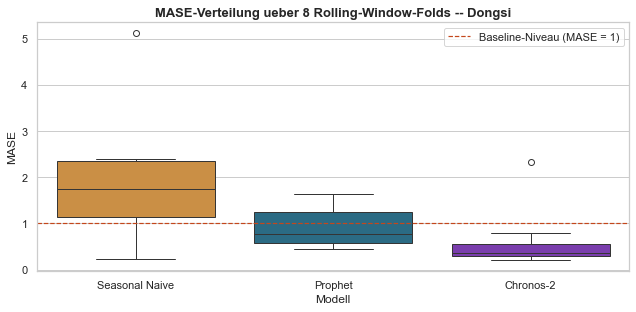

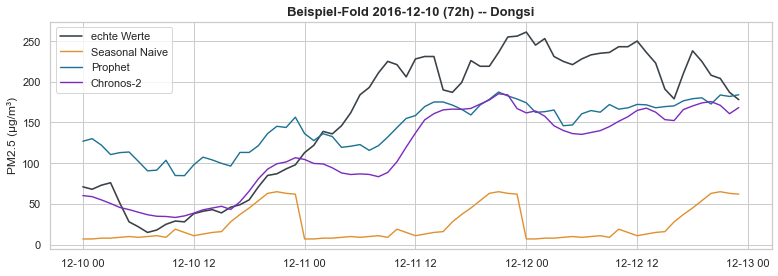

In [34]:
# --- 13.8 Auswertung: Durchschnitt, MASE-Verteilung ueber Folds, Beispiel-Fold -------------------------
print("Durchschnitt ueber alle Folds:")
print(tabelle_rolling.groupby("Modell")[["MAE", "RMSE", "MASE", "MAPE %"]].mean().round(2).to_string())

FARBEN_MODELLE = {"Seasonal Naive": AMBER, "Prophet": TEAL, "Chronos-2": CHRONOSFARBE, "TFT": MOSS}

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=tabelle_rolling, x="Modell", y="MASE",
           palette=[FARBEN_MODELLE.get(m, SLATE) for m in tabelle_rolling["Modell"].unique()])
plt.axhline(1.0, color=RUST, ls="--", lw=1.2, label="Baseline-Niveau (MASE = 1)")
plt.title(f"MASE-Verteilung ueber {len(fold_start_daten)} Rolling-Window-Folds -- {STATION}")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

# Beispiel-Fold (mittlerer Fold) im Detail
beispiel_fold = fold_start_daten[len(fold_start_daten) // 2]
ergebnisse_beispiel = vorhersagen_rolling[beispiel_fold]
irgendein_out = next(iter(ergebnisse_beispiel.values()))

plt.figure(figsize=(11, 4))
plt.plot(irgendein_out["ds"], irgendein_out["y"], color=SLATE, lw=1.6, label="echte Werte")
for modellname, out in ergebnisse_beispiel.items():
    plt.plot(out["ds"], out["yhat"], color=FARBEN_MODELLE.get(modellname, "black"), lw=1.4, label=modellname)
plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
plt.title(f"Beispiel-Fold {beispiel_fold.date()} ({ROLLING_HORIZONT_STUNDEN}h) -- {STATION}")
plt.legend(loc="best"); plt.tight_layout(); plt.show()


### 13.9 Ad-hoc-Vergleich an einem frei wählbaren Split-Datum

Für einen einzelnen Vergleich (statt des ganzen Rolling-Window-Backtests) — nutzt exakt dieselben
Modellfunktionen und, falls verfügbar, das bereits trainierte TFT-Modell (kein erneutes Training). Der
Horizont ist frei wählbar; bei Split-Daten außerhalb `[ROLLING_START, ROLLING_ENDE]` gilt für TFT weiterhin
der Hinweis aus Abschnitt 13: das Modell wurde nur auf Daten vor `ROLLING_START` trainiert, nutzt bei der
Inferenz aber ganz normal die tatsächliche Historie vor dem gewählten Split-Datum als Kontext-Fenster.


In [35]:
# --- 13.9 Mini-Dashboard: Modellvergleich an frei waehlbarem Split-Datum -------------------------------
w3_split     = widgets.DatePicker(description="Split-Datum:", value=pd.Timestamp(ROLLING_START).date())
w3_horizont  = widgets.BoundedIntText(description="Horizont (h):", min=1, max=24 * 30,
                                      value=ROLLING_HORIZONT_STUNDEN, style={"description_width": "initial"})
w3_button    = widgets.Button(description="Vergleichen", button_style="success", icon="play")
w3_output    = widgets.Output()


def on_click_v3(_):
    with w3_output:
        clear_output(wait=True)
        fold_start = pd.Timestamp(w3_split.value)
        ergebnisse_fold, skala = vergleiche_modelle_fenster(
            fold_start, horizont_stunden=w3_horizont.value,
            tft_modell=tft_modell, tft_training_dataset=tft_training_dataset, tft_rahmen=tft_rahmen,
            modelle=modelle_liste,
        )
        zeilen = [{"Modell": m, **jahres_fehler(out, skala)} for m, out in ergebnisse_fold.items()]
        print(f"Split-Datum: {fold_start.date()}  |  Horizont: {w3_horizont.value} h\n")
        print(pd.DataFrame(zeilen).round(2).to_string(index=False))

        plt.figure(figsize=(11, 4))
        irgendein_out = next(iter(ergebnisse_fold.values()))
        plt.plot(irgendein_out["ds"], irgendein_out["y"], color=SLATE, lw=1.6, label="echte Werte")
        for modellname, out in ergebnisse_fold.items():
            plt.plot(out["ds"], out["yhat"], color=FARBEN_MODELLE.get(modellname, "black"), lw=1.4,
                     label=modellname)
        plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
        plt.title(f"Modellvergleich ab {fold_start.date()} ({w3_horizont.value}h) -- {STATION}")
        plt.legend(loc="best"); plt.tight_layout(); plt.show()

w3_button.on_click(on_click_v3)
display(widgets.VBox([widgets.HBox([w3_split, w3_horizont]), w3_button]), w3_output)


Output()

## 11. Ergebnis & Ausblick

**Was dieses Notebook zusätzlich zu den bisherigen zeigt:**

- **Split-Datum als Stellschraube** (Abschnitt 8): Wie stabil MASE/RMSE über verschiedene Trainings-/
  Testzeiträume sind, verrät etwas über die *Robustheit* eines Modells — ein Modell, das nur für einen
  einzelnen, historisch günstigen Split gut aussieht, ist ein schwächeres Ergebnis als eines, das über mehrere
  Split-Punkte hinweg stabil bleibt.
- **Zukunfts-/Vergangenheits-Regressoren als bewusste Design-Entscheidung** (Abschnitt 2/6): Wer nur Variablen
  in `REGRESSOREN_ZUKUNFT` steckt, die *operativ* wirklich im Voraus bekannt sind (z. B. eine echte
  Wettervorhersage statt der gemessenen Werte), bekommt eine realistischere Einschätzung der *operativen*
  Prognosegüte als die (optimistischere) Konfigurationsleiter mit echtem Zukunftswetter.
- **Multivariate Prognose als letzter Schritt** (Abschnitt 9): zeigt, ob das gemeinsame Modellieren aller
  Stationen (Chronos-2s Group-Attention) einen Mehrwert gegenüber unabhängigen Einzelprognosen bringt — dafür
  eignet sich der direkte Vergleich mit einem unabhängigen Stations-Sweep (wie in den anderen Notebooks
  gezeigt) als nächster Schritt.

**Offene, ehrliche Fragen:**

- Bleibt `best_chronos` (Abschnitt 7) auch die beste Konfiguration, wenn man sie **für jedes** Split-Datum aus
  Abschnitt 8 neu bestimmt — oder wechselt der Sieger je nach Testzeitraum?
- Wie stark hängt die multivariate Prognose an der (vereinfachten) **Stadt-Mittelwert-Kovariate** — würden
  echte stationsspezifische Regressoren einen messbaren Unterschied machen?
- Für eine faire Bewertung der `behandelt`-Kappungsgrenze bei einem stark abweichenden `SPLIT_DATUM`: Kapitel 03
  (Datenaufbereitung) mit dem neuen Datum erneut laufen lassen (siehe Warnhinweis in der Einleitung).


In [23]:
# --- 13.5c Schneller Einzel-Test: NUR TFT -------------------------------------------------------------
if TFT_VERFUEGBAR:
    _test_rahmen = baue_tft_rahmen(lade_gesamt("basis", station=STATION), REGRESSOREN_ZUKUNFT,
                                   REGRESSOREN_VERGANGENHEIT, feiertag=True, station=STATION)

    _test_tft, _test_training_dataset = trainiere_tft(
        _test_rahmen, ROLLING_START, REGRESSOREN_ZUKUNFT, REGRESSOREN_VERGANGENHEIT, feiertag=True,
        max_prediction_length=ROLLING_HORIZONT_STUNDEN, max_epochs=5,   # wenige Epochen -- nur ein Rauch-Test
    )

    _test_out = tft_predict_fenster(_test_tft, _test_training_dataset, _test_rahmen,
                                    fold_start=ROLLING_START, horizont_stunden=ROLLING_HORIZONT_STUNDEN)

    _test_tr = _test_rahmen[_test_rahmen["ds"] < pd.Timestamp(ROLLING_START)]
    _test_skala = mase_skala(_test_tr["y"], m=SAISON_M)

    print(f"TFT-Einzeltest -- {STATION} ab {ROLLING_START} ({ROLLING_HORIZONT_STUNDEN}h)\n")
    print(jahres_fehler(_test_out, _test_skala))

    plt.figure(figsize=(10, 4))
    plt.plot(_test_out["ds"], _test_out["y"], color=SLATE, lw=1.6, label="echte Werte")
    plt.plot(_test_out["ds"], _test_out["yhat"], color=MOSS, lw=1.6, label="TFT")
    plt.ylabel("PM2.5 (\u00b5g/m\u00b3)")
    plt.title(f"TFT-Einzeltest -- {STATION} ({ROLLING_HORIZONT_STUNDEN}h ab {ROLLING_START})")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()
else:
    print("TFT nicht verfuegbar -- 'pip install pytorch-forecasting' (siehe Abschnitt 13.1) und Kernel neu starten.")


NameError: name 'TFT_VERFUEGBAR' is not defined